In [2]:
import pandas as pd
import numpy as np

results = pd.read_csv("../datasets/results.csv")
elo = pd.read_csv("../datasets/elo_ratings_wc2026.csv")

<h2>Data Preparation</h2>

<p>Converting the date column into datetime format for easier analysis.</p>

In [3]:
results['date'] = pd.to_datetime(results['date'])

<h2>Filtering Recent Matches</h2>

<p>Keeping matches from 2000 onwards for model training.</p>

In [4]:
recent_matches = results[results['date'] >= '2000-01-01']

print("Original Shape :", results.shape)
print("Filtered Shape :", recent_matches.shape)

Original Shape : (49477, 9)
Filtered Shape : (25415, 9)


<h2>Creating Target Variable</h2>

<p>
Creating match outcome labels for model training:
</p>

<ul>
    <li>0 - Away Team Win</li>
    <li>1 - Draw</li>
    <li>2 - Home Team Win</li>
</ul>

In [5]:
recent_matches['result'] = np.where(
    recent_matches['home_score'] > recent_matches['away_score'], 2,
    np.where(
        recent_matches['home_score'] < recent_matches['away_score'], 0, 1
    )
)

recent_matches[['home_team','away_team','home_score','away_score','result']].head()

C:\Users\laksh\AppData\Local\Temp\ipykernel_30796\2554214608.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_matches['result'] = np.where(


,home_team,away_team,home_score,away_score,result
24062,Egypt,Togo,2.0,1.0,2
24063,Tunisia,Togo,7.0,0.0,2
24064,Trinidad and Tobago,Canada,0.0,0.0,1
24065,Burkina Faso,Gabon,1.0,1.0,1
24066,Guatemala,Armenia,1.0,1.0,1


<h2>Target Variable Distribution</h2>

<p>Checking the distribution of match outcomes.</p>

In [6]:
recent_matches['result'].value_counts()

result
2    12217
0     7241
1     5957
Name: count, dtype: int64

In [7]:
recent_matches['result'].value_counts(normalize=True) * 100

result
2    48.070037
0    28.491049
1    23.438914
Name: proportion, dtype: float64

<h2>Observation</h2>

<p>
Home team wins are the most common outcome in the dataset.
This indicates the presence of home advantage in international football.
</p>

<h2>Latest Elo Ratings</h2>

<p>Viewing the most recent Elo ratings available in the dataset.</p>

In [8]:
elo.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


In [9]:
elo[['country','rating','rank']].head()

,country,rating,rank
0,England,2013,1
1,Scotland,1973,2
2,Argentina,2021,1
3,England,1995,2
4,Scotland,1983,3


In [10]:
elo.sort_values('snapshot_date', ascending=False).head(20)

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
4599,2026,2026-12-31,Japan,13,JP,1904,9,1913,62,1467,...,331,207,297,408,257,170,1517,985,AFC,0
4634,2026,2026-12-31,Qatar,95,QA,1425,26,1771,93,1416,...,328,146,223,289,232,176,993,825,AFC,0
4612,2026,2026-12-31,Iran,31,IR,1760,13,1853,41,1658,...,223,195,250,382,132,154,1270,524,AFC,0
4613,2026,2026-12-31,South Korea,33,KR,1752,16,1845,35,1687,...,353,255,442,571,221,258,1907,964,AFC,0
4614,2026,2026-12-31,Algeria,35,DZ,1743,18,1807,48,1621,...,261,233,194,309,196,183,1052,703,CAF,0
4615,2026,2026-12-31,Panama,36,PA,1737,27,1773,99,1362,...,200,227,164,196,251,144,736,906,CONCACAF,0
4616,2026,2026-12-31,Uzbekistan,38,UZ,1727,25,1766,60,1596,...,130,128,107,180,110,75,635,398,AFC,0
4617,2026,2026-12-31,Czechia,40,CZ,1726,1,2032,13,1855,...,360,416,106,424,261,197,1624,1097,UEFA,0
4618,2026,2026-12-31,United States,41,US,1721,9,1890,41,1642,...,487,253,85,366,286,173,1246,1073,CONCACAF,1
4619,2026,2026-12-31,Sweden,43,SE,1719,2,2013,17,1795,...,489,499,130,549,335,234,2226,1482,UEFA,0


In [11]:
elo['snapshot_date'] = pd.to_datetime(elo['snapshot_date'])

print("Earliest Snapshot:", elo['snapshot_date'].min())
print("Latest Snapshot:", elo['snapshot_date'].max())

Earliest Snapshot: 1901-12-31 00:00:00
Latest Snapshot: 2026-12-31 00:00:00


<h2>Current Elo Ratings</h2>

<p>Extracting the latest Elo rating available for each team.</p>

In [12]:
latest_elo = (
    elo.sort_values('snapshot_date')
       .groupby('country')
       .tail(1)
)

latest_elo = latest_elo[['country', 'rating', 'rank']]

latest_elo.head()

,country,rating,rank
4634,Qatar,1425,95
4607,Austria,1827,23
4606,Paraguay,1833,22
4605,Mexico,1860,20
4604,Belgium,1867,19


<h2>Latest Elo Dataset</h2>

<p>Checking the shape of the extracted Elo ratings dataset.</p>

In [13]:
print(latest_elo.shape)

(48, 3)


In [14]:
fixtures = pd.read_csv("../datasets/wc_2026_fixtures.csv")

<h2>Observation</h2>

<p>
The extracted Elo dataset contains the latest rating and rank for all 48
qualified teams participating in the FIFA World Cup 2026.
</p>

<h2>Checking Team Names</h2>

<p>Comparing team names between the fixtures and Elo datasets.</p>

In [15]:
print("Teams in Elo Dataset:")
print(sorted(latest_elo['country'].unique())[:10])

print("\nTeams in Fixtures Dataset:")
print(sorted(fixtures['team1'].unique())[:10])

set(fixtures['team1']).difference(set(latest_elo['country']))

Teams in Elo Dataset:
['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia']

Teams in Fixtures Dataset:
['1A', '1B', '1C', '1D', '1E', '1F', '1G', '1H', '1I', '1J']


{'1A',
 '1B',
 '1C',
 '1D',
 '1E',
 '1F',
 '1G',
 '1H',
 '1I',
 '1J',
 '1K',
 '1L',
 '3rd Place',
 'Best 3rd #1',
 'Best 3rd #3',
 'Best 3rd #5',
 'Best 3rd #7',
 'Finalist 1',
 'QF1',
 'QF3',
 'QF5',
 'QF7',
 'R32 W1',
 'R32 W11',
 'R32 W13',
 'R32 W15',
 'R32 W3',
 'R32 W5',
 'R32 W7',
 'R32 W9',
 'SF1',
 'SF3',
 'Türkiye',
 'USA'}

<h2>Exploring Elo Ratings</h2>

<p>Checking the strongest teams according to the latest Elo ratings.</p>

In [16]:
latest_elo.sort_values('rating', ascending=False).head(10)

,country,rating,rank
4587,Spain,2165,1
4588,Argentina,2113,2
4589,France,2081,3
4590,England,2020,4
4591,Brazil,1984,5
4592,Portugal,1984,5
4593,Colombia,1975,7
4594,Netherlands,1961,8
4595,Ecuador,1933,9
4596,Croatia,1930,10


<h2>Team Name Matching</h2>

<p>Checking whether team names in the match dataset exist in the Elo dataset.</p>

In [17]:
match_teams = set(recent_matches['home_team']) | set(recent_matches['away_team'])

elo_teams = set(latest_elo['country'])

print("Teams in Matches:", len(match_teams))
print("Teams in Elo:", len(elo_teams))

print("\nTeams Missing in Elo:")
print(match_teams - elo_teams)

Teams in Matches: 321
Teams in Elo: 48

Teams Missing in Elo:
{'Laos', 'Mozambique', 'Kazakhstan', 'Western Isles', 'Rwanda', 'Botswana', 'Fiji', 'Northern Mariana Islands', 'Orkney', 'Mayotte', 'Kabylia', 'Sri Lanka', 'Gabon', 'Hitra', 'Samoa', 'Yorkshire', 'Pakistan', 'Taiwan', 'Sápmi', 'Isle of Man', 'Martinique', 'Bangladesh', 'Yemen', 'United States Virgin Islands', 'Serbia', 'Chagos Islands', 'Kosovo', 'Guam', 'Two Sicilies', 'Kenya', 'Guernsey', 'Padania', 'Georgia', 'Madrid', 'Palestine', 'Eritrea', 'Greece', 'Artsakh', 'Bermuda', 'Tuvalu', 'Székely Land', 'Saint Vincent and the Grenadines', 'Hungary', 'Indonesia', 'Mapuche', 'Vanuatu', 'East Turkestan', 'Maldives', 'Togo', 'Barbados', 'Latvia', 'Estonia', 'Aymara', 'Liberia', 'Åland Islands', 'Délvidék', 'China', 'Sierra Leone', 'Tanzania', 'North Macedonia', 'Singapore', 'Chechnya', 'New Caledonia', 'Guyana', 'Jersey', 'Papua New Guinea', 'Romania', 'Canary Islands', 'Nepal', 'Tonga', 'Malta', 'Saare County', 'Lebanon', 'West

<h2>Observation</h2>

<p>
The current Elo dataset contains ratings for the 48 qualified FIFA World Cup 2026 teams.
A separate historical Elo dataset will be used for feature engineering and model training,
while the current Elo ratings will be used for World Cup 2026 predictions and simulations.
</p>

In [18]:
historical_elo = pd.read_csv("../datasets/historical_elo_ratings.csv")

historical_elo.head()


,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,AB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,671.0,671.0,671.0,671.0,671.0,671.0,671.0,691.0,691.0,691.0
1,AD,NaN,NaN,NaN,NaN,NaN,NaN,1077.0,1067.0,1056.0,...,1012.0,1084.0,1107.0,1036.0,1057.0,1109.0,1102.0,1083.0,1083.0,1077.0
2,AE,1431.0,1431.0,1500.0,1502.0,1530.0,1528.0,1620.0,1544.0,1540.0,...,1563.0,1484.0,1451.0,1429.0,1488.0,1493.0,1530.0,1533.0,1540.0,1540.0
3,AF,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,...,1153.0,1153.0,1140.0,1140.0,1145.0,1098.0,1077.0,1088.0,1035.0,1011.0
4,AG,1222.0,1222.0,1229.0,1210.0,1189.0,1147.0,1118.0,1118.0,1198.0,...,1202.0,1169.0,1156.0,1156.0,1163.0,1163.0,1010.0,917.0,894.0,894.0


In [19]:
historical_elo.shape


(257, 38)

In [20]:
historical_elo.columns.tolist()

['Country',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 '2026']

<h2>Country Code Analysis</h2>

<p>Checking the country codes available in the historical Elo dataset.</p>

In [21]:
historical_elo.head(20)

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,AB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,671.0,671.0,671.0,671.0,671.0,671.0,671.0,691.0,691.0,691.0
1,AD,NaN,NaN,NaN,NaN,NaN,NaN,1077.0,1067.0,1056.0,...,1012.0,1084.0,1107.0,1036.0,1057.0,1109.0,1102.0,1083.0,1083.0,1077.0
2,AE,1431.0,1431.0,1500.0,1502.0,1530.0,1528.0,1620.0,1544.0,1540.0,...,1563.0,1484.0,1451.0,1429.0,1488.0,1493.0,1530.0,1533.0,1540.0,1540.0
3,AF,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,...,1153.0,1153.0,1140.0,1140.0,1145.0,1098.0,1077.0,1088.0,1035.0,1011.0
4,AG,1222.0,1222.0,1229.0,1210.0,1189.0,1147.0,1118.0,1118.0,1198.0,...,1202.0,1169.0,1156.0,1156.0,1163.0,1163.0,1010.0,917.0,894.0,894.0
5,AI,573.0,575.0,574.0,564.0,562.0,528.0,521.0,505.0,497.0,...,552.0,578.0,546.0,546.0,555.0,614.0,547.0,621.0,645.0,646.0
6,AL,1399.0,1441.0,1435.0,1390.0,1364.0,1454.0,1426.0,1411.0,1441.0,...,1608.0,1514.0,1531.0,1556.0,1586.0,1543.0,1631.0,1635.0,1664.0,1646.0
7,AM,NaN,1247.0,1251.0,1251.0,1245.0,1285.0,1336.0,1368.0,1381.0,...,1480.0,1447.0,1450.0,1522.0,1498.0,1451.0,1469.0,1411.0,1389.0,1379.0
8,AN,1352.0,1352.0,1312.0,1312.0,1312.0,1305.0,1241.0,1211.0,1179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AO,1417.0,1386.0,1382.0,1406.0,1405.0,1438.0,1489.0,1537.0,1473.0,...,1239.0,1322.0,1340.0,1350.0,1360.0,1406.0,1385.0,1569.0,1543.0,1543.0


In [22]:
historical_elo['Country'].nunique()

256

In [23]:
historical_elo['Country'].sample(20)

139    MC
24     BJ
218    TE
231    TZ
130    LI
77     FR
113    KE
191    RU
215    SZ
34     BY
84     GL
41     CH
110    JP
42     CI
51     CV
129    LC
89     GR
144    MH
93     GY
29     BQ
Name: Country, dtype: object

<h2>Cleaning Historical Elo Dataset</h2>

<p>Removing rows with missing country codes.</p>

In [24]:
historical_elo = historical_elo.dropna(subset=['Country'])

print(historical_elo.shape)
print(historical_elo['Country'].nunique())

(256, 38)
256


In [25]:
current_elo = pd.read_csv("../datasets/current_elo_ratings.csv")

current_elo.head()

,Rank,Country_Code,Elo_Rating
0,1,ES,2165
1,2,AR,2113
2,3,FR,2082
3,4,EN,2020
4,5,BR,1984


In [26]:
current_elo.shape

(244, 3)

In [27]:
current_elo.columns.tolist()

['Rank', 'Country_Code', 'Elo_Rating']

<h2>Observation</h2>

<p>
Both the historical and current Elo datasets use the same two-letter country
codes. This consistency allows historical Elo ratings to be used for model
training and current Elo ratings to be used for FIFA World Cup 2026 predictions.
</p>

In [28]:
historical_codes = set(historical_elo['Country'])
current_codes = set(current_elo['Country_Code'])

print("Only in Historical:")
print(historical_codes - current_codes)

print("\nCount:", len(historical_codes - current_codes))

Only in Historical:
{'KU', 'YU', 'MK', 'OR', 'SZ', 'RV', 'RM', 'SU', 'CS', 'WM', 'ZR', 'AN', 'KT'}

Count: 13


In [29]:
current_elo.head(20)

,Rank,Country_Code,Elo_Rating
0,1,ES,2165
1,2,AR,2113
2,3,FR,2082
3,4,EN,2020
4,5,BR,1984
5,5,PT,1984
6,7,CO,1975
7,8,NL,1961
8,9,EC,1933
9,10,HR,1930


In [30]:
latest_elo.sort_values('rating', ascending=False).head(20)

,country,rating,rank
4587,Spain,2165,1
4588,Argentina,2113,2
4589,France,2081,3
4590,England,2020,4
4591,Brazil,1984,5
4592,Portugal,1984,5
4593,Colombia,1975,7
4594,Netherlands,1961,8
4595,Ecuador,1933,9
4596,Croatia,1930,10


<h2>Extracting Match Year</h2>

<p>Creating a year column to match historical Elo ratings with match dates.</p>

In [31]:
recent_matches['year'] = recent_matches['date'].dt.year

recent_matches[['date','year']].head()

C:\Users\laksh\AppData\Local\Temp\ipykernel_30796\3753714065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_matches['year'] = recent_matches['date'].dt.year


,date,year
24062,2000-01-04,2000
24063,2000-01-07,2000
24064,2000-01-08,2000
24065,2000-01-09,2000
24066,2000-01-09,2000


<h2>Team Name Mapping</h2>

<p>Mapping team names to Elo country codes.</p>

In [32]:
team_to_code = {
    "Argentina": "AR",
    "Brazil": "BR",
    "France": "FR",
    "England": "EN",
    "Spain": "ES",
    "Portugal": "PT",
    "Colombia": "CO",
    "Netherlands": "NL",
    "Ecuador": "EC",
    "Croatia": "HR",
    "Germany": "DE",
    "Norway": "NO",
    "Japan": "JP",
    "Turkey": "TR",
    "Uruguay": "UY",
    "Switzerland": "CH",
    "Senegal": "SN",
    "Denmark": "DK",
    "Belgium": "BE",
    "Mexico": "MX"
}

<h2>Reshaping Historical Elo Dataset</h2>

<p>Converting Elo ratings from wide format to long format.</p>

In [33]:
elo_long = historical_elo.melt(
    id_vars='Country',
    var_name='year',
    value_name='elo_rating'
)

elo_long.head()

,Country,year,elo_rating
0,AB,1990,NaN
1,AD,1990,NaN
2,AE,1990,1431.0
3,AF,1990,872.0
4,AG,1990,1222.0


In [34]:
elo_long.shape

(9472, 3)

In [35]:
elo_long = elo_long.dropna(subset=['elo_rating'])

print(elo_long.shape)

elo_long.head()

(8613, 3)


,Country,year,elo_rating
2,AE,1990,1431.0
3,AF,1990,872.0
4,AG,1990,1222.0
5,AI,1990,573.0
6,AL,1990,1399.0


In [36]:
elo_long['year'] = elo_long['year'].astype(int)

elo_long.dtypes

Country        object
year            int64
elo_rating    float64
dtype: object

<h2>Checking One Team</h2>

<p>Viewing historical Elo ratings for Argentina.</p>

In [37]:
elo_long[elo_long['Country'] == 'AR'].head(20)

,Country,year,elo_rating
10,AR,1990,1874.0
266,AR,1991,1985.0
522,AR,1992,2029.0
778,AR,1993,1928.0
1034,AR,1994,1884.0
1290,AR,1995,1846.0
1546,AR,1996,1796.0
1802,AR,1997,1834.0
2058,AR,1998,1932.0
2314,AR,1999,1938.0


<h2>Adding Elo Codes</h2>

<p>Mapping team names in match data to Elo country codes.</p>

In [38]:
recent_matches = recent_matches.copy()

recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)

recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

In [39]:
print("Home Missing :", recent_matches['home_code'].isna().sum())
print("Away Missing :", recent_matches['away_code'].isna().sum())

Home Missing : 21828
Away Missing : 22324


In [40]:
len(match_teams)

321

In [41]:
sorted(list(match_teams))[:50]

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde']

In [42]:
sorted(list(match_teams))[-50:]

['Surrey',
 'Sweden',
 'Switzerland',
 'Syria',
 'Székely Land',
 'Sápmi',
 'São Tomé and Príncipe',
 'Tahiti',
 'Taiwan',
 'Tajikistan',
 'Tamil Eelam',
 'Tanzania',
 'Thailand',
 'Tibet',
 'Ticino',
 'Timor-Leste',
 'Togo',
 'Tonga',
 'Trinidad and Tobago',
 'Tunisia',
 'Turkey',
 'Turkmenistan',
 'Turks and Caicos Islands',
 'Tuvalu',
 'Two Sicilies',
 'Uganda',
 'Ukraine',
 'United Arab Emirates',
 'United Koreans in Japan',
 'United States',
 'United States Virgin Islands',
 'Uruguay',
 'Uzbekistan',
 'Vanuatu',
 'Vatican City',
 'Venezuela',
 'Vietnam',
 'Wales',
 'West Papua',
 'Western Armenia',
 'Western Isles',
 'Western Sahara',
 'Yemen',
 'Ynys Môn',
 'Yorkshire',
 'Yoruba Nation',
 'Zambia',
 'Zanzibar',
 'Zimbabwe',
 'Åland Islands']

<h2>World Cup Teams Mapping</h2>

<p>Creating Elo country codes for the 48 qualified teams.</p>

In [43]:
teams = pd.read_csv("../datasets/wc_2026_teams.csv")

In [44]:
teams.head()

,team,group,confederation,fifa_rank,coach,best_wc_result,debut_2026
0,Mexico,A,CONCACAF,15,Javier Aguirre,"Quarter-finals (1970,1986)",No
1,South Africa,A,CAF,60,Hugo Broos,"Group stage (1998,2002,2010)",No
2,South Korea,A,AFC,25,Hong Myung-bo,Semi-finals (2002),No
3,Czechia,A,UEFA,41,Ivan Hasek,"Runner-up (1934,1962)",No
4,Canada,B,CONCACAF,30,Jesse Marsch,"Group stage (1986,2022)",No


In [45]:
teams['team'].sort_values().tolist()

['Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Bosnia and Herzegovina',
 'Brazil',
 'Canada',
 'Cape Verde',
 'Colombia',
 'Croatia',
 'Curaçao',
 'Czechia',
 'DR Congo',
 'Ecuador',
 'Egypt',
 'England',
 'France',
 'Germany',
 'Ghana',
 'Haiti',
 'Iran',
 'Iraq',
 'Ivory Coast',
 'Japan',
 'Jordan',
 'Mexico',
 'Morocco',
 'Netherlands',
 'New Zealand',
 'Norway',
 'Panama',
 'Paraguay',
 'Portugal',
 'Qatar',
 'Saudi Arabia',
 'Scotland',
 'Senegal',
 'South Africa',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Tunisia',
 'Türkiye',
 'USA',
 'Uruguay',
 'Uzbekistan']

<h2>Checking Elo Codes</h2>

<p>Comparing World Cup teams with available Elo country codes.</p>

In [46]:
current_elo['Country_Code'].dropna().sort_values().unique()

array(['AB', 'AD', 'AE', 'AF', 'AG', 'AI', 'AL', 'AM', 'AO', 'AR', 'AS',
       'AT', 'AU', 'AW', 'AZ', 'BA', 'BB', 'BD', 'BE', 'BF', 'BG', 'BH',
       'BI', 'BJ', 'BL', 'BM', 'BN', 'BO', 'BQ', 'BR', 'BS', 'BT', 'BW',
       'BY', 'BZ', 'CA', 'CC', 'CD', 'CF', 'CG', 'CH', 'CI', 'CK', 'CL',
       'CM', 'CN', 'CO', 'CR', 'CU', 'CV', 'CW', 'CX', 'CY', 'CZ', 'DE',
       'DJ', 'DK', 'DM', 'DO', 'DZ', 'EC', 'EE', 'EG', 'EH', 'EI', 'EN',
       'ER', 'ES', 'ET', 'EU', 'FI', 'FJ', 'FK', 'FM', 'FO', 'FR', 'GA',
       'GD', 'GE', 'GF', 'GH', 'GI', 'GL', 'GM', 'GN', 'GP', 'GQ', 'GR',
       'GT', 'GU', 'GW', 'GY', 'HG', 'HK', 'HN', 'HR', 'HT', 'HU', 'ID',
       'IE', 'IL', 'IN', 'IQ', 'IR', 'IS', 'IT', 'JM', 'JO', 'JP', 'JS',
       'KD', 'KE', 'KG', 'KH', 'KI', 'KM', 'KN', 'KO', 'KP', 'KR', 'KW',
       'KY', 'KZ', 'LA', 'LB', 'LC', 'LI', 'LK', 'LR', 'LS', 'LT', 'LU',
       'LV', 'LY', 'MA', 'MC', 'MD', 'ME', 'MF', 'MG', 'MH', 'ML', 'MM',
       'MN', 'MO', 'MP', 'MQ', 'MR', 'MS', 'MT', 'M

In [47]:
current_elo[current_elo['Country_Code'].isin(
    ['DZ','CV','CW','CD','CI','SQ','TR','US','KR']
)]
# check for special/ rare teams 


,Rank,Country_Code,Elo_Rating
13,14,TR,1902
28,29,SQ,1767
31,32,KR,1752
34,35,DZ,1743
40,41,US,1721
51,52,CI,1676
53,54,CD,1655
71,72,CV,1549
89,90,CW,1436


In [48]:
team_to_code_wc = {
    "Argentina": "AR",
    "Australia": "AU",
    "Austria": "AT",
    "Belgium": "BE",
    "Bosnia and Herzegovina": "BA",
    "Brazil": "BR",
    "Canada": "CA",
    "Cape Verde": "CV",
    "Colombia": "CO",
    "Croatia": "HR",
    "Curaçao": "CW",
    "Czechia": "CZ",
    "DR Congo": "CD",
    "Ecuador": "EC",
    "Egypt": "EG",
    "England": "EN",
    "France": "FR",
    "Germany": "DE",
    "Ghana": "GH",
    "Haiti": "HT",
    "Iran": "IR",
    "Iraq": "IQ",
    "Ivory Coast": "CI",
    "Japan": "JP",
    "Jordan": "JO",
    "Mexico": "MX",
    "Morocco": "MA",
    "Netherlands": "NL",
    "New Zealand": "NZ",
    "Norway": "NO",
    "Panama": "PA",
    "Paraguay": "PY",
    "Portugal": "PT",
    "Qatar": "QA",
    "Saudi Arabia": "SA",
    "Scotland": "SQ",
    "Senegal": "SN",
    "South Africa": "ZA",
    "South Korea": "KR",
    "Spain": "ES",
    "Sweden": "SE",
    "Switzerland": "CH",
    "Tunisia": "TN",
    "Türkiye": "TR",
    "USA": "US",
    "Uruguay": "UY",
    "Uzbekistan": "UZ"
}

<h2>Mapping Coverage Check</h2>

<p>Checking if all World Cup teams have an Elo code.</p>

In [49]:
missing = set(teams['team']) - set(team_to_code_wc.keys())

print("Missing Teams:", len(missing))
print(missing)

Missing Teams: 1
{'Algeria'}


In [50]:
team_to_code_wc["Algeria"] = "DZ"

In [51]:
missing = set(teams['team']) - set(team_to_code_wc.keys())

print("Missing Teams:", len(missing))
print(missing)

Missing Teams: 0
set()


<h2>Creating Elo Lookup Table</h2>

<p>Creating a quick lookup table for team codes, years, and Elo ratings.</p>

In [52]:
elo_lookup = elo_long.set_index(['Country', 'year'])['elo_rating']

elo_lookup.head()

Country  year
AE       1990    1431.0
AF       1990     872.0
AG       1990    1222.0
AI       1990     573.0
AL       1990    1399.0
Name: elo_rating, dtype: float64

In [53]:
elo_lookup[('AR', 2014)]

np.float64(2050.0)

<h2>Adding Team Codes to Matches</h2>

<p>Mapping home and away teams to their Elo country codes.</p>

In [54]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code_wc)

recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code_wc)

recent_matches[['home_team','home_code','away_team','away_code']].head()

,home_team,home_code,away_team,away_code
24062,Egypt,EG,Togo,NaN
24063,Tunisia,TN,Togo,NaN
24064,Trinidad and Tobago,NaN,Canada,CA
24065,Burkina Faso,NaN,Gabon,NaN
24066,Guatemala,NaN,Armenia,NaN


<h2>Creating Elo Features</h2>

<p>Extracting Elo ratings for both teams using match year.</p>

In [55]:
def get_elo(code, year):
    try:
        return elo_lookup[(code, year)]
    except:
        return np.nan

In [56]:
recent_matches['home_elo'] = recent_matches.apply(
    lambda row: get_elo(row['home_code'], row['year']),
    axis=1
)

recent_matches['away_elo'] = recent_matches.apply(
    lambda row: get_elo(row['away_code'], row['year']),
    axis=1
)

<h2>Elo Difference Feature</h2>

<p>Calculating the Elo rating gap between the two teams.</p>

In [57]:
recent_matches['elo_difference'] = (
    recent_matches['home_elo'] -
    recent_matches['away_elo']
)

recent_matches[
    ['home_team','away_team','home_elo','away_elo','elo_difference']
].head()

,home_team,away_team,home_elo,away_elo,elo_difference
24062,Egypt,Togo,1682.0,NaN,NaN
24063,Tunisia,Togo,1637.0,NaN,NaN
24064,Trinidad and Tobago,Canada,NaN,1632.0,NaN
24065,Burkina Faso,Gabon,NaN,NaN,NaN
24066,Guatemala,Armenia,NaN,NaN,NaN


In [58]:
recent_matches[
    ['home_elo','away_elo','elo_difference']
].isna().sum()

home_elo          17854
away_elo          18586
elo_difference    22548
dtype: int64

In [59]:
print("Match Teams :", len(match_teams))
print("Historical Elo Codes :", historical_elo['Country'].nunique())

Match Teams : 321
Historical Elo Codes : 256


In [60]:
sorted(list(match_teams))[:50]

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde']

In [61]:
sorted(list(match_teams))

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China',
 'Cilento',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Crimea',
 'Croatia',
 'Cuba',
 'Curaçao',
 'C

In [62]:
official_teams = [
    'Afghanistan','Albania','Algeria','Andorra','Angola',
    'Antigua and Barbuda','Argentina','Armenia','Aruba',
    'Australia','Austria','Azerbaijan','Bahamas','Bahrain',
    'Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bermuda','Bhutan','Bolivia',
    'Bosnia and Herzegovina','Botswana','Brazil',
    'British Virgin Islands','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon',
    'Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros',
    'Congo','Cook Islands','Costa Rica','Croatia',
    'Cuba','Curaçao','Cyprus','Czech Republic',
    'DR Congo','Denmark','Djibouti','Dominica',
    'Dominican Republic','Ecuador','Egypt',
    'El Salvador','England','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia',
    'Faroe Islands','Fiji','Finland','France',
    'French Guiana','Gabon','Gambia','Georgia',
    'Germany','Ghana','Gibraltar','Greece',
    'Greenland','Grenada','Guadeloupe','Guam',
    'Guatemala','Guernsey','Guinea','Guinea-Bissau',
    'Guyana','Haiti','Honduras','Hong Kong',
    'Hungary','Iceland','India','Indonesia',
    'Iran','Iraq','Israel','Italy','Ivory Coast',
    'Jamaica','Japan','Jersey','Jordan',
    'Kazakhstan','Kenya','Kosovo','Kuwait',
    'Kyrgyzstan','Laos','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Liechtenstein',
    'Lithuania','Luxembourg','Macau','Madagascar',
    'Malawi','Malaysia','Maldives','Mali',
    'Malta','Martinique','Mauritania','Mauritius',
    'Mexico','Micronesia','Moldova','Monaco',
    'Mongolia','Montenegro','Montserrat',
    'Morocco','Mozambique','Myanmar','Namibia',
    'Nepal','Netherlands','New Caledonia',
    'New Zealand','Nicaragua','Niger',
    'Nigeria','North Korea','North Macedonia',
    'Northern Ireland','Northern Mariana Islands',
    'Norway','Oman','Pakistan','Palestine',
    'Panama','Papua New Guinea','Paraguay',
    'Peru','Philippines','Poland','Portugal',
    'Puerto Rico','Qatar','Republic of Ireland',
    'Romania','Russia','Rwanda','Samoa',
    'San Marino','Saudi Arabia','Scotland',
    'Senegal','Serbia','Seychelles',
    'Sierra Leone','Singapore','Sint Maarten',
    'Slovakia','Slovenia','Solomon Islands',
    'Somalia','South Africa','South Korea',
    'South Sudan','Spain','Sri Lanka',
    'Sudan','Suriname','Sweden','Switzerland',
    'Syria','São Tomé and Príncipe','Tahiti',
    'Taiwan','Tajikistan','Tanzania',
    'Thailand','Timor-Leste','Togo',
    'Tonga','Trinidad and Tobago','Tunisia',
    'Turkey','Turkmenistan',
    'Turks and Caicos Islands','Tuvalu',
    'Uganda','Ukraine','United Arab Emirates',
    'United States','United States Virgin Islands',
    'Uruguay','Uzbekistan','Vanuatu',
    'Venezuela','Vietnam','Wales','Yemen',
    'Zambia','Zimbabwe'
]

In [63]:
recent_matches = recent_matches[
    recent_matches['home_team'].isin(official_teams) &
    recent_matches['away_team'].isin(official_teams)
]

In [64]:
print(recent_matches.shape)

(23841, 16)


In [65]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)
recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

print("Home Missing:", recent_matches['home_code'].isna().sum())
print("Away Missing:", recent_matches['away_code'].isna().sum())

Home Missing: 20256
Away Missing: 20763


In [66]:
sorted(set(recent_matches.loc[
    recent_matches['home_code'].isna(),
    'home_team'
]))

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech Republic',
 'DR Congo',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Faroe Islands',
 'Fiji',
 'Finland',
 'French Guiana',
 'Gabon',
 'Gambia',
 'Georgia',
 'Ghana',
 'Gibraltar',
 'Greece',
 'Greenland',
 'Grenada',
 'Guadeloupe',
 'Guam',
 'Guatemala',
 'Guernsey',
 'Guinea',
 'Guinea-Bissau',
 'Gu

In [67]:
current_elo[current_elo['Country_Code'] == 'AF']

,Rank,Country_Code,Elo_Rating
182,183,AF,1011


In [68]:
team_to_code.update({
    "Afghanistan":"AF",
    "Albania":"AL",
    "Andorra":"AD",
    "Angola":"AO",
    "Armenia":"AM",
    "Azerbaijan":"AZ",
    "Bahamas":"BS",
    "Bahrain":"BH",
    "Bangladesh":"BD",
    "Barbados":"BB",
    "Belarus":"BY",
    "Belize":"BZ",
    "Benin":"BJ",
    "Bermuda":"BM",
    "Bhutan":"BT",
    "Bosnia and Herzegovina":"BA",
    "Botswana":"BW",
    "Brunei":"BN",
    "Bulgaria":"BG",
    "Burkina Faso":"BF",
    "Burundi":"BI",
    "Cambodia":"KH",
    "Central African Republic":"CF",
    "Chad":"TD",
    "China":"CN",
    "Comoros":"KM",
    "Congo":"CG",
    "Costa Rica":"CR",
    "Cuba":"CU",
    "Cyprus":"CY",
    "Czech Republic":"CZ",
    "Djibouti":"DJ",
    "Dominica":"DM",
    "Dominican Republic":"DO",
    "El Salvador":"SV",
    "Equatorial Guinea":"GQ",
    "Eritrea":"ER",
    "Estonia":"EE",
    "Eswatini":"SZ",
    "Ethiopia":"ET",
    "Faroe Islands":"FO",
    "Fiji":"FJ",
    "Gabon":"GA",
    "Gambia":"GM",
    "Georgia":"GE",
    "Greece":"GR",
    "Guatemala":"GT",
    "Guinea":"GN",
    "Guinea-Bissau":"GW",
    "Guyana":"GY",
    "Haiti":"HT",
    "Honduras":"HN",
    "Hong Kong":"HK",
    "Hungary":"HU",
    "Iceland":"IS",
    "India":"IN",
    "Indonesia":"ID",
    "Israel":"IL",
    "Jamaica":"JM",
    "Kazakhstan":"KZ",
    "Kenya":"KE",
    "Kosovo":"XK",
    "Kuwait":"KW",
    "Kyrgyzstan":"KG",
    "Laos":"LA",
    "Latvia":"LV",
    "Lebanon":"LB",
    "Lesotho":"LS",
    "Liberia":"LR",
    "Libya":"LY",
    "Liechtenstein":"LI",
    "Lithuania":"LT",
    "Luxembourg":"LU",
    "Macau":"MO",
    "Madagascar":"MG",
    "Malawi":"MW",
    "Malaysia":"MY",
    "Maldives":"MV",
    "Mali":"ML",
    "Malta":"MT",
    "Mauritania":"MR",
    "Mauritius":"MU",
    "Moldova":"MD",
    "Mongolia":"MN",
    "Montenegro":"ME",
    "Mozambique":"MZ",
    "Myanmar":"MM",
    "Namibia":"NA",
    "Nepal":"NP",
    "Nicaragua":"NI",
    "Niger":"NE",
    "North Korea":"KP",
    "North Macedonia":"MK",
    "Oman":"OM",
    "Pakistan":"PK",
    "Palestine":"PS",
    "Papua New Guinea":"PG",
    "Philippines":"PH",
    "Romania":"RO",
    "Russia":"RU",
    "Rwanda":"RW",
    "San Marino":"SM",
    "Serbia":"RS",
    "Seychelles":"SC",
    "Sierra Leone":"SL",
    "Singapore":"SG",
    "Slovakia":"SK",
    "Slovenia":"SI",
    "Somalia":"SO",
    "South Sudan":"SS",
    "Sri Lanka":"LK",
    "Sudan":"SD",
    "Suriname":"SR",
    "Syria":"SY",
    "Tajikistan":"TJ",
    "Tanzania":"TZ",
    "Thailand":"TH",
    "Timor-Leste":"TL",
    "Togo":"TG",
    "Tonga":"TO",
    "Turkmenistan":"TM",
    "Uganda":"UG",
    "Ukraine":"UA",
    "Vanuatu":"VU",
    "Vietnam":"VN",
    "Yemen":"YE",
    "Zambia":"ZM",
    "Zimbabwe":"ZW"
})

In [69]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)
recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

print(recent_matches['home_code'].isna().sum())
print(recent_matches['away_code'].isna().sum())

7313
6980


In [70]:
missing_home = sorted(
    set(recent_matches.loc[recent_matches['home_code'].isna(), 'home_team'])
)

print("Missing Home Teams:", len(missing_home))
missing_home

Missing Home Teams: 67


['Algeria',
 'Antigua and Barbuda',
 'Aruba',
 'Australia',
 'Austria',
 'Bolivia',
 'British Virgin Islands',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Chile',
 'Cook Islands',
 'Curaçao',
 'DR Congo',
 'Egypt',
 'Finland',
 'French Guiana',
 'Ghana',
 'Gibraltar',
 'Greenland',
 'Grenada',
 'Guadeloupe',
 'Guam',
 'Guernsey',
 'Iran',
 'Iraq',
 'Italy',
 'Ivory Coast',
 'Jersey',
 'Jordan',
 'Martinique',
 'Micronesia',
 'Montserrat',
 'Morocco',
 'New Caledonia',
 'New Zealand',
 'Nigeria',
 'Northern Ireland',
 'Northern Mariana Islands',
 'Panama',
 'Paraguay',
 'Peru',
 'Poland',
 'Puerto Rico',
 'Qatar',
 'Republic of Ireland',
 'Samoa',
 'Saudi Arabia',
 'Scotland',
 'Sint Maarten',
 'Solomon Islands',
 'South Africa',
 'South Korea',
 'Sweden',
 'São Tomé and Príncipe',
 'Tahiti',
 'Taiwan',
 'Trinidad and Tobago',
 'Tunisia',
 'Turks and Caicos Islands',
 'Tuvalu',
 'United Arab Emirates',
 'United States',
 'United States Virgin Islands',
 'Uzbekistan',
 'Venezuela',
 'Wales'

In [71]:
missing_away = sorted(
    set(recent_matches.loc[recent_matches['away_code'].isna(), 'away_team'])
)

print("Missing Away Teams:", len(missing_away))
missing_away

Missing Away Teams: 68


['Algeria',
 'Antigua and Barbuda',
 'Aruba',
 'Australia',
 'Austria',
 'Bolivia',
 'British Virgin Islands',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Chile',
 'Cook Islands',
 'Curaçao',
 'DR Congo',
 'Egypt',
 'Finland',
 'French Guiana',
 'Ghana',
 'Gibraltar',
 'Greenland',
 'Grenada',
 'Guadeloupe',
 'Guam',
 'Guernsey',
 'Iran',
 'Iraq',
 'Italy',
 'Ivory Coast',
 'Jersey',
 'Jordan',
 'Martinique',
 'Micronesia',
 'Monaco',
 'Montserrat',
 'Morocco',
 'New Caledonia',
 'New Zealand',
 'Nigeria',
 'Northern Ireland',
 'Northern Mariana Islands',
 'Panama',
 'Paraguay',
 'Peru',
 'Poland',
 'Puerto Rico',
 'Qatar',
 'Republic of Ireland',
 'Samoa',
 'Saudi Arabia',
 'Scotland',
 'Sint Maarten',
 'Solomon Islands',
 'South Africa',
 'South Korea',
 'Sweden',
 'São Tomé and Príncipe',
 'Tahiti',
 'Taiwan',
 'Trinidad and Tobago',
 'Tunisia',
 'Turks and Caicos Islands',
 'Tuvalu',
 'United Arab Emirates',
 'United States',
 'United States Virgin Islands',
 'Uzbekistan',
 'Venezuela

In [72]:
team_to_code.update({
    "Cape Verde": "CV",
    "Curaçao": "CW",
    "DR Congo": "CD",
    "Faroe Islands": "FO",
    "Guadeloupe": "GP",
    "Martinique": "MQ",
    "Montserrat": "MS",
    "New Caledonia": "NC",
    "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR",
    "São Tomé and Príncipe": "ST",
    "Tahiti": "PF",
    "Turks and Caicos Islands": "TC",
    "United States Virgin Islands": "VI",
    "British Virgin Islands": "VG",
    "Macau": "MO",
    "Sint Maarten": "SX",
    "Cook Islands": "CK",
    "Guam": "GU",
    "American Samoa": "AS"
})

In [73]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)
recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

print(recent_matches['home_code'].isna().sum())
print(recent_matches['away_code'].isna().sum())

6592
6137


In [74]:
missing = sorted(
    set(recent_matches.loc[recent_matches['home_code'].isna(), 'home_team']) |
    set(recent_matches.loc[recent_matches['away_code'].isna(), 'away_team'])
)

print("Missing Teams:", len(missing))
print(missing)

Missing Teams: 51
['Algeria', 'Antigua and Barbuda', 'Aruba', 'Australia', 'Austria', 'Bolivia', 'Cameroon', 'Canada', 'Chile', 'Egypt', 'Finland', 'French Guiana', 'Ghana', 'Gibraltar', 'Greenland', 'Grenada', 'Guernsey', 'Iran', 'Iraq', 'Italy', 'Ivory Coast', 'Jersey', 'Jordan', 'Micronesia', 'Monaco', 'Morocco', 'New Zealand', 'Nigeria', 'Northern Ireland', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Qatar', 'Republic of Ireland', 'Samoa', 'Saudi Arabia', 'Scotland', 'Solomon Islands', 'South Africa', 'South Korea', 'Sweden', 'Taiwan', 'Trinidad and Tobago', 'Tunisia', 'Tuvalu', 'United Arab Emirates', 'United States', 'Uzbekistan', 'Venezuela', 'Wales']


In [75]:
for team in sorted(missing):
    if team in team_to_code:
        print(team, "->", team_to_code[team])

In [76]:
team_to_code.get("United States")

In [77]:
len(team_to_code)


166

In [78]:

list(team_to_code.items())[:10]

[('Argentina', 'AR'),
 ('Brazil', 'BR'),
 ('France', 'FR'),
 ('England', 'EN'),
 ('Spain', 'ES'),
 ('Portugal', 'PT'),
 ('Colombia', 'CO'),
 ('Netherlands', 'NL'),
 ('Ecuador', 'EC'),
 ('Croatia', 'HR')]

In [79]:
"United States" in team_to_code

False

In [80]:
len(team_to_code_wc)

48

In [81]:
historical_elo.head()

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,AB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,671.0,671.0,671.0,671.0,671.0,671.0,671.0,691.0,691.0,691.0
1,AD,NaN,NaN,NaN,NaN,NaN,NaN,1077.0,1067.0,1056.0,...,1012.0,1084.0,1107.0,1036.0,1057.0,1109.0,1102.0,1083.0,1083.0,1077.0
2,AE,1431.0,1431.0,1500.0,1502.0,1530.0,1528.0,1620.0,1544.0,1540.0,...,1563.0,1484.0,1451.0,1429.0,1488.0,1493.0,1530.0,1533.0,1540.0,1540.0
3,AF,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,872.0,...,1153.0,1153.0,1140.0,1140.0,1145.0,1098.0,1077.0,1088.0,1035.0,1011.0
4,AG,1222.0,1222.0,1229.0,1210.0,1189.0,1147.0,1118.0,1118.0,1198.0,...,1202.0,1169.0,1156.0,1156.0,1163.0,1163.0,1010.0,917.0,894.0,894.0


In [82]:
historical_elo['Country'].sample(20)

147    MM
52     CW
200    SI
8      AN
135    LU
115    KH
16     BA
47     CO
226    TO
228    TT
133    LS
143    MG
138    MA
29     BQ
149    MO
88     GQ
188    RM
178    PK
116    KI
204    SN
Name: Country, dtype: object

In [83]:
team_to_code = {
    "Afghanistan":"AF",
    "Albania":"AL",
    "Algeria":"DZ",
    "Andorra":"AD",
    "Angola":"AO",
    "Antigua and Barbuda":"AG",
    "Armenia":"AM",
    "Aruba":"AW",
    "Australia":"AU",
    "Austria":"AT",
    "Azerbaijan":"AZ",
    "Bahamas":"BS",
    "Bahrain":"BH",
    "Bangladesh":"BD",
    "Barbados":"BB",
    "Belarus":"BY",
    "Belize":"BZ",
    "Benin":"BJ",
    "Bermuda":"BM",
    "Bhutan":"BT",
    "Bolivia":"BO",
    "Bosnia and Herzegovina":"BA",
    "Botswana":"BW",
    "British Virgin Islands":"VG",
    "Brunei":"BN",
    "Bulgaria":"BG",
    "Burkina Faso":"BF",
    "Burundi":"BI",
    "Cambodia":"KH",
    "Cameroon":"CM",
    "Canada":"CA",
    "Cape Verde":"CV",
    "Central African Republic":"CF",
    "Chad":"TD",
    "Chile":"CL",
    "China":"CN",
    "Comoros":"KM",
    "Congo":"CG",
    "Cook Islands":"CK",
    "Costa Rica":"CR",
    "Cuba":"CU",
    "Curaçao":"CW",
    "Cyprus":"CY",
    "Czech Republic":"CZ",
    "DR Congo":"CD",
    "Djibouti":"DJ",
    "Dominica":"DM",
    "Dominican Republic":"DO",
    "Egypt":"EG",
    "El Salvador":"SV",
    "Equatorial Guinea":"GQ",
    "Eritrea":"ER",
    "Estonia":"EE",
    "Eswatini":"SZ",
    "Ethiopia":"ET",
    "Faroe Islands":"FO",
    "Fiji":"FJ",
    "Finland":"FI",
    "French Guiana":"GF",
    "Gabon":"GA",
    "Gambia":"GM",
    "Georgia":"GE",
    "Ghana":"GH",
    "Gibraltar":"GI",
    "Greece":"GR",
    "Greenland":"GL",
    "Grenada":"GD",
    "Guadeloupe":"GP",
    "Guam":"GU",
    "Guatemala":"GT",
    "Guernsey":"GG",
    "Guinea":"GN",
    "Guinea-Bissau":"GW",
    "Guyana":"GY",
    "Haiti":"HT",
    "Honduras":"HN",
    "Hong Kong":"HK",
    "Hungary":"HU",
    "Iceland":"IS",
    "India":"IN",
    "Indonesia":"ID",
    "Iran":"IR",
    "Iraq":"IQ",
    "Israel":"IL",
    "Italy":"IT",
    "Ivory Coast":"CI",
    "Jamaica":"JM",
    "Japan":"JP",
    "Jersey":"JE",
    "Jordan":"JO",
    "Kazakhstan":"KZ",
    "Kenya":"KE",
    "Kosovo":"XK",
    "Kuwait":"KW",
    "Kyrgyzstan":"KG",
    "Laos":"LA",
    "Latvia":"LV",
    "Lebanon":"LB",
    "Lesotho":"LS",
    "Liberia":"LR",
    "Libya":"LY",
    "Liechtenstein":"LI",
    "Lithuania":"LT",
    "Luxembourg":"LU",
    "Macau":"MO",
    "Madagascar":"MG",
    "Malawi":"MW",
    "Malaysia":"MY",
    "Maldives":"MV",
    "Mali":"ML",
    "Malta":"MT",
    "Martinique":"MQ",
    "Mauritania":"MR",
    "Mauritius":"MU",
    "Micronesia":"FM",
    "Moldova":"MD",
    "Monaco":"MC",
    "Mongolia":"MN",
    "Montenegro":"ME",
    "Montserrat":"MS",
    "Morocco":"MA",
    "Mozambique":"MZ",
    "Myanmar":"MM",
    "Namibia":"NA",
    "Nepal":"NP",
    "New Caledonia":"NC",
    "New Zealand":"NZ",
    "Nicaragua":"NI",
    "Niger":"NE",
    "Nigeria":"NG",
    "North Korea":"KP",
    "North Macedonia":"MK",
    "Northern Ireland":"NIR",
    "Oman":"OM",
    "Pakistan":"PK",
    "Palestine":"PS",
    "Panama":"PA",
    "Papua New Guinea":"PG",
    "Paraguay":"PY",
    "Peru":"PE",
    "Philippines":"PH",
    "Poland":"PL",
    "Puerto Rico":"PR",
    "Qatar":"QA",
    "Republic of Ireland":"IE",
    "Romania":"RO",
    "Russia":"RU",
    "Rwanda":"RW",
    "Samoa":"WS",
    "San Marino":"SM",
    "Saudi Arabia":"SA",
    "Scotland":"SQ",
    "Serbia":"RS",
    "Seychelles":"SC",
    "Sierra Leone":"SL",
    "Singapore":"SG",
    "Sint Maarten":"SX",
    "Slovakia":"SK",
    "Slovenia":"SI",
    "Solomon Islands":"SB",
    "Somalia":"SO",
    "South Africa":"ZA",
    "South Korea":"KR",
    "South Sudan":"SS",
    "Sri Lanka":"LK",
    "Sudan":"SD",
    "Suriname":"SR",
    "Sweden":"SE",
    "Syria":"SY",
    "São Tomé and Príncipe":"ST",
    "Tahiti":"PF",
    "Taiwan":"TW",
    "Tajikistan":"TJ",
    "Tanzania":"TZ",
    "Thailand":"TH",
    "Timor-Leste":"TL",
    "Togo":"TG",
    "Tonga":"TO",
    "Trinidad and Tobago":"TT",
    "Tunisia":"TN",
    "Turkmenistan":"TM",
    "Turks and Caicos Islands":"TC",
    "Tuvalu":"TV",
    "Uganda":"UG",
    "Ukraine":"UA",
    "United Arab Emirates":"AE",
    "United States":"US",
    "United States Virgin Islands":"VI",
    "Uzbekistan":"UZ",
    "Vanuatu":"VU",
    "Venezuela":"VE",
    "Vietnam":"VN",
    "Wales":"WA",
    "Yemen":"YE",
    "Zambia":"ZM",
    "Zimbabwe":"ZW"
}

In [84]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)
recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

print("Home Missing:", recent_matches['home_code'].isna().sum())
print("Away Missing:", recent_matches['away_code'].isna().sum())

Home Missing: 3337
Away Missing: 2953


In [85]:
missing_home = sorted(
    recent_matches.loc[recent_matches['home_code'].isna(), 'home_team'].unique()
)

print(len(missing_home))
print(missing_home)

20
['Argentina', 'Belgium', 'Brazil', 'Colombia', 'Croatia', 'Denmark', 'Ecuador', 'England', 'France', 'Germany', 'Mexico', 'Netherlands', 'Northern Mariana Islands', 'Norway', 'Portugal', 'Senegal', 'Spain', 'Switzerland', 'Turkey', 'Uruguay']


In [86]:
missing_away = sorted(
    recent_matches.loc[recent_matches['away_code'].isna(), 'away_team'].unique()
)

print(len(missing_away))
print(missing_away)

20
['Argentina', 'Belgium', 'Brazil', 'Colombia', 'Croatia', 'Denmark', 'Ecuador', 'England', 'France', 'Germany', 'Mexico', 'Netherlands', 'Northern Mariana Islands', 'Norway', 'Portugal', 'Senegal', 'Spain', 'Switzerland', 'Turkey', 'Uruguay']


In [87]:
for team in missing_home:
    print(team, "->", team_to_code.get(team))

Argentina -> None
Belgium -> None
Brazil -> None
Colombia -> None
Croatia -> None
Denmark -> None
Ecuador -> None
England -> None
France -> None
Germany -> None
Mexico -> None
Netherlands -> None
Northern Mariana Islands -> None
Norway -> None
Portugal -> None
Senegal -> None
Spain -> None
Switzerland -> None
Turkey -> None
Uruguay -> None


In [88]:
for team in missing_home:
    code = team_to_code.get(team)
    print(team, code, code in set(historical_elo['Country']))

Argentina None False
Belgium None False
Brazil None False
Colombia None False
Croatia None False
Denmark None False
Ecuador None False
England None False
France None False
Germany None False
Mexico None False
Netherlands None False
Northern Mariana Islands None False
Norway None False
Portugal None False
Senegal None False
Spain None False
Switzerland None False
Turkey None False
Uruguay None False


In [89]:
"Argentina" in team_to_code

False

In [90]:
print(len(team_to_code))
print(list(team_to_code.keys())[:20])

196
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Benin', 'Bermuda', 'Bhutan']


In [91]:
team_to_code.update({
    "Argentina":"AR",
    "Belgium":"BE",
    "Brazil":"BR",
    "Colombia":"CO",
    "Croatia":"HR",
    "Denmark":"DK",
    "Ecuador":"EC",
    "England":"EN",
    "France":"FR",
    "Germany":"DE",
    "Mexico":"MX",
    "Netherlands":"NL",
    "Northern Mariana Islands":"MP",
    "Norway":"NO",
    "Portugal":"PT",
    "Senegal":"SN",
    "Spain":"ES",
    "Switzerland":"CH",
    "Turkey":"TR",
    "Uruguay":"UY"
})

In [92]:
"Argentina" in team_to_code

True

In [93]:
recent_matches['home_code'] = recent_matches['home_team'].map(team_to_code)
recent_matches['away_code'] = recent_matches['away_team'].map(team_to_code)

print("Home Missing:", recent_matches['home_code'].isna().sum())
print("Away Missing:", recent_matches['away_code'].isna().sum())

Home Missing: 0
Away Missing: 0


In [94]:
recent_matches['year'] = recent_matches['date'].dt.year

In [95]:
recent_matches['home_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['home_code'], str(x['year'])), np.nan),
    axis=1
)

recent_matches['away_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['away_code'], str(x['year'])), np.nan),
    axis=1
)

recent_matches['elo_difference'] = (
    recent_matches['home_elo'] -
    recent_matches['away_elo']
)

In [96]:
recent_matches[
    ['home_team','away_team','home_elo','away_elo','elo_difference']
].head()

,home_team,away_team,home_elo,away_elo,elo_difference
24062,Egypt,Togo,NaN,NaN,NaN
24063,Tunisia,Togo,NaN,NaN,NaN
24064,Trinidad and Tobago,Canada,NaN,NaN,NaN
24065,Burkina Faso,Gabon,NaN,NaN,NaN
24066,Guatemala,Armenia,NaN,NaN,NaN


In [97]:
recent_matches[
    ['home_elo','away_elo','elo_difference']
].isna().sum()

home_elo          23841
away_elo          23841
elo_difference    23841
dtype: int64

In [98]:
elo_lookup.get(('AR', 2014))

np.float64(2050.0)

In [99]:
recent_matches['year'] = recent_matches['year'].astype(int)

In [100]:
row = recent_matches.iloc[0]

print(row['home_team'])
print(row['home_code'])
print(row['year'])

print(
    elo_lookup.get(
        (row['home_code'], row['year'])
    )
)

Egypt
EG
2000
1682.0


In [101]:
recent_matches['home_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['home_code'], x['year']), np.nan),
    axis=1
)

recent_matches['away_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['away_code'], x['year']), np.nan),
    axis=1
)

In [102]:
recent_matches[['home_code','away_code','year']].head()

,home_code,away_code,year
24062,EG,TG,2000
24063,TN,TG,2000
24064,TT,CA,2000
24065,BF,GA,2000
24066,GT,AM,2000


In [103]:
row = recent_matches.iloc[0]

print(row['home_code'])
print(row['year'])

print(elo_lookup.get((row['home_code'], row['year'])))

EG
2000
1682.0


In [104]:
recent_matches['home_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['home_code'], x['year']), np.nan),
    axis=1
)

recent_matches['away_elo'] = recent_matches.apply(
    lambda x: elo_lookup.get((x['away_code'], x['year']), np.nan),
    axis=1
)

recent_matches['elo_difference'] = (
    recent_matches['home_elo'] -
    recent_matches['away_elo']
)

In [105]:
recent_matches[
    ['home_elo','away_elo','elo_difference']
].isna().sum()

home_elo          458
away_elo          489
elo_difference    916
dtype: int64

In [106]:
missing_home = sorted(
    recent_matches.loc[
        recent_matches['home_elo'].isna(),
        'home_team'
    ].unique()
)

print(len(missing_home))
print(missing_home)

10
['Curaçao', 'Eswatini', 'Guernsey', 'Jersey', 'Kosovo', 'Namibia', 'North Macedonia', 'Northern Ireland', 'Serbia', 'Tahiti']


In [107]:
recent_matches = recent_matches.dropna(
    subset=['home_elo', 'away_elo']
)

print(recent_matches.shape)

(22925, 16)


In [108]:
recent_matches[
    ['home_elo','away_elo','elo_difference']
].isna().sum()

home_elo          0
away_elo          0
elo_difference    0
dtype: int64

# Adding Historical Elo Ratings

## Why Elo?

Just using past match results does not tell us how strong a team actually was at that time. To include team strength in the model, historical Elo ratings were added.

Elo ratings give a numerical measure of a team's performance and are updated after every match. Strong teams generally have higher Elo values.

---

## Understanding the Dataset

Two Elo datasets were available:

- `current_elo_ratings.csv`
- `historical_elo_ratings.csv`

The current Elo file contains the latest ratings of teams, while the historical Elo file contains ratings for every year from 1990 onwards.

After checking the dataset, I found that the historical Elo dataset had around 256 country codes and yearly ratings from 1990 to 2026.

---

## Reshaping the Historical Elo Data

The historical Elo dataset was originally stored in a wide format where each year was a separate column.

For example:

| Country | 1990 | 1991 | 1992 |
|----------|------|------|------|
| AR | 1874 | 1985 | 2029 |

Since I needed ratings based on both country and year, I converted the dataset into a long format using `melt()`.

After reshaping:

| Country | year | elo_rating |
|----------|------|-----------|
| AR | 1990 | 1874 |
| AR | 1991 | 1985 |
| AR | 1992 | 2029 |

This format was much easier to work with.

---

## Mapping Team Names to Country Codes

The match dataset contained full team names such as:

- Argentina
- Brazil
- France
- Spain

However, the Elo dataset used country codes such as:

- AR
- BR
- FR
- ES

To connect both datasets, I created a dictionary that maps team names to their corresponding country codes.

Initially, many teams were not mapped correctly, so I manually expanded the dictionary until every required team was covered.

Final check:

Missing Teams = 0

---

## Creating Elo Features

After the mapping was completed, I created a lookup table using:

(Country Code, Year)

This allowed me to quickly fetch the Elo rating of any team for any particular year.

Using this lookup, three new features were added:

- `home_elo`
- `away_elo`
- `elo_difference`

where

```python
elo_difference = home_elo - away_elo

# Adding FIFA Rankings

## Objective

Historical Elo ratings capture the long-term strength of a team. To further improve the prediction model, FIFA World Rankings are added as another feature.

Unlike Elo ratings, FIFA rankings are officially released by FIFA and provide another measure of a team's current competitive position.

The goal is to assign the latest FIFA ranking to every team in the dataset and create ranking-based features for model training.

In [109]:
fifa = pd.read_csv("../datasets/fifa_rankings_.csv")
fifa.head()

,Team,FIFA_Rank
0,Argentina,1
1,Spain,2
2,France,3
3,England,4
4,Portugal,5


# Creating FIFA Rank Mapping

We create a dictionary that maps each team to its FIFA ranking. This will help us quickly assign rankings to every match.

In [110]:
team_to_rank = dict(zip(fifa['Team'], fifa['FIFA_Rank']))

In [111]:
print(team_to_rank["Argentina"])
print(team_to_rank["Brazil"])
print(team_to_rank["England"])

1
6
4


In [112]:
missing = set(teams['team']) - set(team_to_rank.keys())

print("Missing Teams:", len(missing))
print(sorted(missing))

Missing Teams: 3
['Cape Verde', 'DR Congo', 'New Zealand']


In [113]:
team_to_rank.update({

    "USA": 17,
    "Türkiye": 26,
    "Czechia": 46,
    "Ivory Coast": 52,
    "Bosnia and Herzegovina": 62,
    "Curaçao": 90,
    "DR Congo": 61,
    "Ghana": 76,
    "Haiti": 83,
    "Paraguay": 48,
    "Qatar": 55,
    "Saudi Arabia": 58,
    "Scotland": 44

})

In [114]:
team_to_rank.update({

    "Cape Verde": team_to_rank["Cabo Verde"],
    "New Zealand": 54

})

In [115]:
missing = set(teams['team']) - set(team_to_rank.keys())

print("Missing Teams:", len(missing))
print(sorted(missing))

Missing Teams: 0
[]


# Adding FIFA Ranking Features

Now we add the FIFA ranking of both teams to every match. These features will help the model compare the strength of the two teams.

In [116]:
recent_matches["home_fifa_rank"] = recent_matches["home_team"].map(team_to_rank)
recent_matches["away_fifa_rank"] = recent_matches["away_team"].map(team_to_rank)

In [117]:
recent_matches[
    ["home_team","away_team","home_fifa_rank","away_fifa_rank"]
].head()

,home_team,away_team,home_fifa_rank,away_fifa_rank
24062,Egypt,Togo,29.0,110.0
24063,Tunisia,Togo,45.0,110.0
24064,Trinidad and Tobago,Canada,89.0,30.0
24065,Burkina Faso,Gabon,63.0,83.0
24066,Guatemala,Armenia,90.0,91.0


In [118]:
recent_matches[
    ["home_fifa_rank","away_fifa_rank"]
].isna().sum()

home_fifa_rank    2057
away_fifa_rank    2173
dtype: int64

# Removing Missing FIFA Rankings

Some historical matches still do not have FIFA rankings because the teams are not present in the FIFA ranking dataset. These matches are removed before training the model.

In [119]:
recent_matches = recent_matches.dropna(
    subset=["home_fifa_rank", "away_fifa_rank"]
)

print(recent_matches.shape)

(18947, 18)


In [120]:
recent_matches[
    ["home_fifa_rank", "away_fifa_rank"]
].isna().sum()

home_fifa_rank    0
away_fifa_rank    0
dtype: int64

# Adding Host Advantage

The 2026 FIFA World Cup is hosted by the United States, Canada, and Mexico. A new feature is created to indicate whether a team is playing in its home country.

In [121]:
host_countries = [
    "United States",
    "Canada",
    "Mexico"
]

In [122]:
recent_matches["home_host"] = recent_matches["home_team"].isin(host_countries).astype(int)

recent_matches["away_host"] = recent_matches["away_team"].isin(host_countries).astype(int)

In [123]:
recent_matches[
    ["home_team","away_team","home_host","away_host"]
].sample(10)

,home_team,away_team,home_host,away_host
33804,Slovakia,Cameroon,0,0
28638,Thailand,Jordan,0,0
39682,Mexico,Paraguay,1,0
24218,England,Argentina,0,0
24992,Lebanon,Iraq,0,0
33776,Portugal,Cape Verde,0,0
25684,Japan,Australia,0,0
45910,Austria,Azerbaijan,0,0
36633,Honduras,El Salvador,0,0
28148,Solomon Islands,New Caledonia,0,0


In [124]:
print("Home Hosts :", recent_matches["home_host"].sum())
print("Away Hosts :", recent_matches["away_host"].sum())

Home Hosts : 362
Away Hosts : 251


# Creating Host Advantage

Instead of using two separate columns, we create a single feature that shows which team has the home-country advantage.

- 1 : Home team is a host nation
- -1 : Away team is a host nation
- 0 : Neither team is a host nation

In [125]:
recent_matches["host_advantage"] = (
    recent_matches["home_host"] -
    recent_matches["away_host"]
)

In [126]:
recent_matches[
    [
        "home_team",
        "away_team",
        "home_host",
        "away_host",
        "host_advantage"
    ]
].sample(10)

,home_team,away_team,home_host,away_host,host_advantage
47416,Uruguay,Panama,0,0,0
32389,Antigua and Barbuda,Guyana,0,0,0
42246,Philippines,China,0,0,0
37928,Brazil,Germany,0,0,0
40061,Bosnia and Herzegovina,Estonia,0,0,0
33370,Portugal,Hungary,0,0,0
46512,Latvia,Armenia,0,0,0
26222,Senegal,Tunisia,0,0,0
46693,Algeria,Somalia,0,0,0
32950,China,Germany,0,0,0


In [127]:
recent_matches["host_advantage"].value_counts()

host_advantage
 0    18362
 1      348
-1      237
Name: count, dtype: int64

# Adding Recent Form

Recent form shows how well a team has performed in its last five matches before the current game. This feature helps the model capture the team's current momentum.

In [128]:
recent_matches = recent_matches.sort_values("date").reset_index(drop=True)

recent_matches[["date","home_team","away_team"]].head()

,date,home_team,away_team
0,2000-01-04,Egypt,Togo
1,2000-01-07,Tunisia,Togo
2,2000-01-08,Trinidad and Tobago,Canada
3,2000-01-09,Burkina Faso,Gabon
4,2000-01-09,Guatemala,Armenia


# World Cup Start Dates

To calculate the recent form of each team, we first store the starting date of every FIFA World Cup. This helps us find the last five matches played before each tournament.

In [129]:
wc_start_dates = {

    1994: "1994-06-17",
    1998: "1998-06-10",
    2002: "2002-05-31",
    2006: "2006-06-09",
    2010: "2010-06-11",
    2014: "2014-06-12",
    2018: "2018-06-14",
    2022: "2022-11-20",
    2026: "2026-06-11"

}

In [130]:
wc_start_dates = {
    year: pd.to_datetime(date)
    for year, date in wc_start_dates.items()
}

In [131]:
wc_start_dates

{1994: Timestamp('1994-06-17 00:00:00'),
 1998: Timestamp('1998-06-10 00:00:00'),
 2002: Timestamp('2002-05-31 00:00:00'),
 2006: Timestamp('2006-06-09 00:00:00'),
 2010: Timestamp('2010-06-11 00:00:00'),
 2014: Timestamp('2014-06-12 00:00:00'),
 2018: Timestamp('2018-06-14 00:00:00'),
 2022: Timestamp('2022-11-20 00:00:00'),
 2026: Timestamp('2026-06-11 00:00:00')}

# Assigning World Cup Year

Each historical match is assigned to the next World Cup. This helps us calculate the recent form of every team before the tournament starts.

In [132]:
def get_wc_year(match_date):

    for year, start_date in wc_start_dates.items():

        if match_date < start_date:
            return year

    return None

In [133]:
recent_matches["wc_year"] = recent_matches["date"].apply(get_wc_year)

In [134]:
recent_matches[
    ["date","home_team","away_team","wc_year"]
].head(10)

,date,home_team,away_team,wc_year
0,2000-01-04,Egypt,Togo,2002.0
1,2000-01-07,Tunisia,Togo,2002.0
2,2000-01-08,Trinidad and Tobago,Canada,2002.0
3,2000-01-09,Burkina Faso,Gabon,2002.0
4,2000-01-09,Guatemala,Armenia,2002.0
5,2000-01-09,Ivory Coast,Egypt,2002.0
6,2000-01-09,Mexico,Iran,2002.0
7,2000-01-11,Bermuda,Canada,2002.0
8,2000-01-11,Burkina Faso,Cameroon,2002.0
9,2000-01-13,Senegal,Cameroon,2002.0


In [135]:
recent_matches["wc_year"].value_counts().sort_index()

wc_year
2002.0    1833
2006.0    2758
2010.0    2864
2014.0    2997
2018.0    2714
2022.0    3006
2026.0    2711
Name: count, dtype: int64

# Creating Team Match History

To calculate recent form, we first group all matches played by each team. This allows us to quickly access a team's previous matches before a World Cup.

In [136]:
team_matches = {}

all_teams = sorted(
    set(recent_matches["home_team"]) |
    set(recent_matches["away_team"])
)

for team in all_teams:

    matches = recent_matches[
        (recent_matches["home_team"] == team) |
        (recent_matches["away_team"] == team)
    ].sort_values("date")

    team_matches[team] = matches.reset_index(drop=True)

In [137]:
print(len(team_matches))

list(team_matches.keys())[:10]

183


['Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria']

In [138]:
team_matches["Argentina"].head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,away_code,home_elo,away_elo,elo_difference,home_fifa_rank,away_fifa_rank,home_host,away_host,host_advantage,wc_year
0,2000-02-23,England,Argentina,0.0,0.0,Friendly,London,England,False,1,...,AR,1852.0,2005.0,-153.0,4.0,1.0,0,0,0,2002.0
1,2000-04-26,Venezuela,Argentina,0.0,4.0,FIFA World Cup qualification,Maracaibo,Venezuela,False,0,...,AR,1413.0,2005.0,-592.0,49.0,1.0,0,0,0,2002.0
2,2000-06-29,Colombia,Argentina,1.0,3.0,FIFA World Cup qualification,Bogotá,Colombia,False,0,...,AR,1768.0,2005.0,-237.0,13.0,1.0,0,0,0,2002.0
3,2000-07-19,Argentina,Ecuador,2.0,0.0,FIFA World Cup qualification,Buenos Aires,Argentina,False,2,...,EC,2005.0,1692.0,313.0,1.0,23.0,0,0,0,2002.0
4,2000-07-26,Brazil,Argentina,3.0,1.0,FIFA World Cup qualification,São Paulo,Brazil,False,2,...,AR,2023.0,2005.0,18.0,6.0,1.0,0,0,0,2002.0


# Calculating Recent Form

A function is created to calculate the recent form of a team before a World Cup. It looks at the team's last five matches played before the tournament starts and returns performance statistics.

# Creating Recent Form Function

A function is created to calculate the last five matches played by a team before a particular World Cup. These matches will later be used to calculate the team's recent form.

In [139]:
'''def get_recent_form(team, wc_year):

    matches = team_matches[team]

    start_date = wc_start_dates[wc_year]

    matches = matches[
        matches["date"] < start_date
    ]

    return matches.tail(5)'''

'def get_recent_form(team, wc_year):\n\n    matches = team_matches[team]\n\n    start_date = wc_start_dates[wc_year]\n\n    matches = matches[\n        matches["date"] < start_date\n    ]\n\n    return matches.tail(5)'

In [140]:
'''arg = get_recent_form("Argentina", 2018)

arg[
    ["date","home_team","away_team","home_score","away_score"]
]'''

'arg = get_recent_form("Argentina", 2018)\n\narg[\n    ["date","home_team","away_team","home_score","away_score"]\n]'

# Calculating Recent Form Statistics

The selected five matches are used to calculate the team's recent performance before the World Cup. The statistics include wins, draws, losses, goals scored, goals conceded and total points.

In [141]:
def get_recent_form(team, wc_year):

    matches = team_matches[team]

    start_date = wc_start_dates[wc_year]

    matches = matches[
        matches["date"] < start_date
    ].tail(5)

    wins = 0
    draws = 0
    losses = 0

    goals_scored = 0
    goals_conceded = 0

    points = 0

    for _, row in matches.iterrows():

        if row["home_team"] == team:

            gf = row["home_score"]
            ga = row["away_score"]

        else:

            gf = row["away_score"]
            ga = row["home_score"]

        goals_scored += gf
        goals_conceded += ga

        if gf > ga:

            wins += 1
            points += 3

        elif gf == ga:

            draws += 1
            points += 1

        else:

            losses += 1

    return {
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "goals_scored": goals_scored,
        "goals_conceded": goals_conceded,
        "goal_difference": goals_scored - goals_conceded,
        "points": points
    }

In [142]:
get_recent_form("Argentina", 2018)

{'wins': 3,
 'draws': 0,
 'losses': 2,
 'goals_scored': 10.0,
 'goals_conceded': 10.0,
 'goal_difference': 0.0,
 'points': 9}

# Adding Recent Form Features

The recent form function is applied to every match. Separate statistics are generated for the home and away teams using their last five matches before the corresponding World Cup.

In [143]:
recent_matches["home_form_points"] = 0
recent_matches["away_form_points"] = 0

recent_matches["home_goal_diff"] = 0
recent_matches["away_goal_diff"] = 0

recent_matches["home_wins_last5"] = 0
recent_matches["away_wins_last5"] = 0

In [144]:
recent_matches["wc_year"].isna().sum()

np.int64(64)

In [145]:
recent_matches[
    recent_matches["wc_year"].isna()
][["date","home_team","away_team"]].head(20)

,date,home_team,away_team
18883,2026-06-11,Mexico,South Africa
18884,2026-06-12,Canada,Bosnia and Herzegovina
18885,2026-06-13,Qatar,Switzerland
18886,2026-06-13,Brazil,Morocco
18887,2026-06-13,Haiti,Scotland
18888,2026-06-14,Sweden,Tunisia
18889,2026-06-14,Netherlands,Japan
18890,2026-06-14,Ivory Coast,Ecuador
18891,2026-06-14,Germany,Curaçao
18892,2026-06-15,Saudi Arabia,Uruguay


In [146]:
recent_matches = recent_matches.dropna(subset=["wc_year"])

recent_matches["wc_year"] = recent_matches["wc_year"].astype(int)

recent_matches["wc_year"].isna().sum()

np.int64(0)

# Generating Recent Form Features

The recent form function is now applied to every match. A progress bar is used to monitor the feature generation process.

In [147]:
from tqdm import tqdm

tqdm.pandas()

In [148]:
for i in tqdm(recent_matches.index):

    row = recent_matches.loc[i]

    home_form = get_recent_form(
        row["home_team"],
        row["wc_year"]
    )

    away_form = get_recent_form(
        row["away_team"],
        row["wc_year"]
    )

    recent_matches.at[i, "home_form_points"] = home_form["points"]
    recent_matches.at[i, "away_form_points"] = away_form["points"]

    recent_matches.at[i, "home_goal_diff"] = home_form["goal_difference"]
    recent_matches.at[i, "away_goal_diff"] = away_form["goal_difference"]

    recent_matches.at[i, "home_wins_last5"] = home_form["wins"]
    recent_matches.at[i, "away_wins_last5"] = away_form["wins"]

100%|██████████| 18883/18883 [00:59<00:00, 319.97it/s]


In [149]:
recent_matches[
    [
        "home_form_points",
        "away_form_points",
        "home_goal_diff",
        "away_goal_diff",
        "home_wins_last5",
        "away_wins_last5"
    ]
].isna().sum()

home_form_points    0
away_form_points    0
home_goal_diff      0
away_goal_diff      0
home_wins_last5     0
away_wins_last5     0
dtype: int64

In [150]:
recent_matches[
    [
        "home_team",
        "away_team",
        "home_form_points",
        "away_form_points",
        "home_goal_diff",
        "away_goal_diff",
        "home_wins_last5",
        "away_wins_last5"
    ]
].head(10)

,home_team,away_team,home_form_points,away_form_points,home_goal_diff,away_goal_diff,home_wins_last5,away_wins_last5
0,Egypt,Togo,7,6,0,-2,2,1
1,Tunisia,Togo,3,6,-2,-2,0,1
2,Trinidad and Tobago,Canada,7,9,-3,2,2,3
3,Burkina Faso,Gabon,2,8,-4,2,0,2
4,Guatemala,Armenia,4,3,-3,-6,1,0
5,Ivory Coast,Egypt,5,7,0,0,1,2
6,Mexico,Iran,13,9,8,1,4,3
7,Bermuda,Canada,8,9,8,2,2,3
8,Burkina Faso,Cameroon,2,4,-4,-1,0,0
9,Senegal,Cameroon,10,4,3,-1,3,0


In [151]:
recent_matches[
    [
        "home_form_points",
        "away_form_points",
        "home_wins_last5",
        "away_wins_last5"
    ]
].describe()


,home_form_points,away_form_points,home_wins_last5,away_wins_last5
count,18883.000000,18883.000000,18883.000000,18883.000000
mean,6.554255,6.284171,1.780014,1.687073
std,3.438669,3.413301,1.221263,1.204138
min,0.000000,0.000000,0.000000,0.000000
25%,4.000000,4.000000,1.000000,1.000000
50%,6.000000,6.000000,2.000000,2.000000
75%,9.000000,9.000000,3.000000,2.000000
max,15.000000,15.000000,5.000000,5.000000


# Creating Target Variable

The target variable represents the actual result of each match. It is created using the final score and will be used to train the machine learning models.

In [152]:
def get_result(home_score, away_score):

    if home_score > away_score:
        return 2

    elif home_score == away_score:
        return 1

    else:
        return 0

In [153]:
recent_matches["result"] = recent_matches.apply(

    lambda row: get_result(
        row["home_score"],
        row["away_score"]
    ),

    axis=1

)

In [154]:
recent_matches[
    [
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "result"
    ]
].head(10)

,home_team,away_team,home_score,away_score,result
0,Egypt,Togo,2.0,1.0,2
1,Tunisia,Togo,7.0,0.0,2
2,Trinidad and Tobago,Canada,0.0,0.0,1
3,Burkina Faso,Gabon,1.0,1.0,1
4,Guatemala,Armenia,1.0,1.0,1
5,Ivory Coast,Egypt,2.0,0.0,2
6,Mexico,Iran,2.0,1.0,2
7,Bermuda,Canada,0.0,2.0,0
8,Burkina Faso,Cameroon,2.0,2.0,1
9,Senegal,Cameroon,0.0,0.0,1


In [155]:
recent_matches["result"].value_counts()

result
2    9013
0    5336
1    4534
Name: count, dtype: int64

In [156]:
recent_matches["rank_difference"] = (
    recent_matches["away_fifa_rank"] -
    recent_matches["home_fifa_rank"]
)

recent_matches["form_difference"] = (
    recent_matches["home_form_points"] -
    recent_matches["away_form_points"]
)

recent_matches["wins_difference"] = (
    recent_matches["home_wins_last5"] -
    recent_matches["away_wins_last5"]
)

recent_matches["goal_diff_difference"] = (
    recent_matches["home_goal_diff"] -
    recent_matches["away_goal_diff"]
)

In [157]:
recent_matches[
    [
        "home_fifa_rank",
        "away_fifa_rank",
        "rank_difference",
        "home_form_points",
        "away_form_points",
        "form_difference"
    ]
].head()

,home_fifa_rank,away_fifa_rank,rank_difference,home_form_points,away_form_points,form_difference
0,29.0,110.0,81.0,7,6,1
1,45.0,110.0,65.0,3,6,-3
2,89.0,30.0,-59.0,7,9,-2
3,63.0,83.0,20.0,2,8,-6
4,90.0,91.0,1.0,4,3,1


In [158]:
features = [

    "home_elo",
    "away_elo",
    "elo_difference",

    "home_fifa_rank",
    "away_fifa_rank",
    "rank_difference",

    "home_form_points",
    "away_form_points",
    "form_difference",

    "home_goal_diff",
    "away_goal_diff",
    "goal_diff_difference",

    "home_wins_last5",
    "away_wins_last5",
    "wins_difference",

    "host_advantage"

]

# Preparing Training Data

The selected features are separated into input features (X) and the target variable (y). These will be used to train and evaluate the machine learning models.

In [159]:
X = recent_matches[features]

y = recent_matches["result"]

In [160]:
print(X.shape)
print(y.shape)

(18883, 16)
(18883,)


In [161]:
from sklearn.model_selection import train_test_split

In [162]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [163]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(15106, 16)
(3777, 16)
(15106,)
(3777,)


In [164]:
print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

result
2    0.477294
0    0.282603
1    0.240103
Name: proportion, dtype: float64

result
2    0.477363
0    0.282499
1    0.240138
Name: proportion, dtype: float64


# Training Random Forest Model

A Random Forest classifier is trained as the baseline model. Its performance will be compared with XGBoost to determine the most suitable model for predicting FIFA World Cup match outcomes.

In [165]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [166]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

In [167]:
rf_model.fit(

    X_train,

    y_train

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [168]:
rf_predictions = rf_model.predict(X_test)

In [169]:
accuracy = accuracy_score(

    y_test,

    rf_predictions

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.5875


In [170]:
print(

    classification_report(

        y_test,

        rf_predictions

    )

)

              precision    recall  f1-score   support

           0       0.57      0.62      0.59      1067
           1       0.29      0.17      0.21       907
           2       0.67      0.78      0.72      1803

    accuracy                           0.59      3777
   macro avg       0.51      0.52      0.51      3777
weighted avg       0.55      0.59      0.56      3777



In [171]:
confusion_matrix(

    y_test,

    rf_predictions

)

array([[ 665,  161,  241],
       [ 310,  152,  445],
       [ 197,  204, 1402]])

# Feature Importance

Random Forest provides feature importance scores, showing how much each feature contributes to predicting match outcomes.

In [172]:
importance = pd.DataFrame({

    "Feature": features,
    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
2,elo_difference,0.214734
5,rank_difference,0.112114
1,away_elo,0.101490
0,home_elo,0.096664
4,away_fifa_rank,0.069502
3,home_fifa_rank,0.067527
11,goal_diff_difference,0.060531
10,away_goal_diff,0.048833
9,home_goal_diff,0.048749
8,form_difference,0.046246


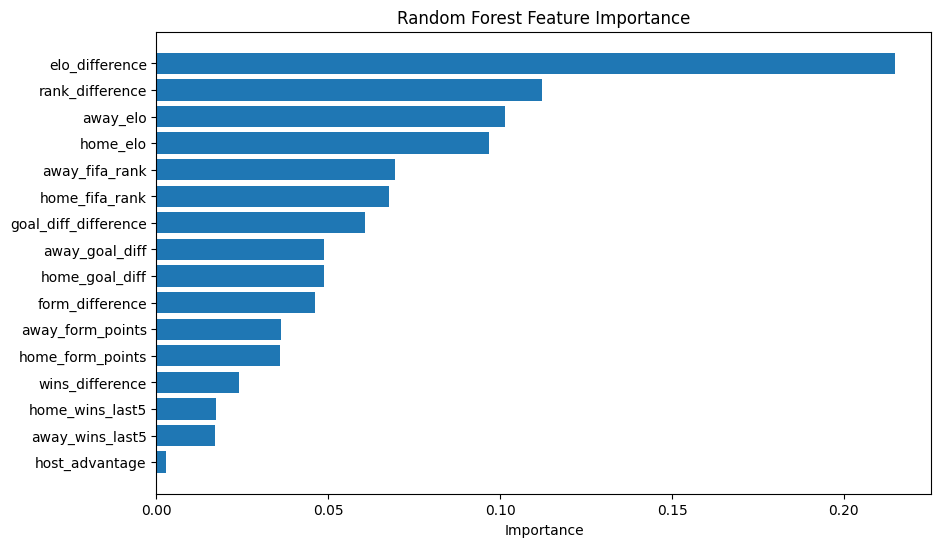

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

# Cross Validation

A 5-fold cross validation is performed to evaluate the Random Forest model on multiple train-test splits. This provides a more reliable estimate of model performance than a single train-test split.

In [174]:
from sklearn.model_selection import cross_val_score

In [175]:
cv_scores = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

In [176]:
print("Cross Validation Scores")

print(cv_scores)

print()

print(f"Mean Accuracy : {cv_scores.mean():.4f}")

print(f"Std Deviation : {cv_scores.std():.4f}")

Cross Validation Scores
[0.60788986 0.6076251  0.59465184 0.60699153 0.62288136]

Mean Accuracy : 0.6080
Std Deviation : 0.0090


In [177]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [10, 20, 30, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

In [178]:
from sklearn.model_selection import RandomizedSearchCV


random_search = RandomizedSearchCV(

    rf_model,

    param_distributions=param_grid,

    n_iter=50,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    random_state=42,

    verbose=3

)

In [179]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [180]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


In [181]:
print(random_search.best_score_)

0.61975375986011


# Evaluating Tuned Random Forest

The best Random Forest model obtained from RandomizedSearchCV is evaluated on the unseen test dataset to compare its performance with the baseline model.

In [182]:
best_rf = random_search.best_estimator_

In [183]:
best_predictions = best_rf.predict(X_test)

In [184]:
accuracy = accuracy_score(

    y_test,

    best_predictions

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6182


In [185]:
print(

    classification_report(

        y_test,

        best_predictions

    )

)

              precision    recall  f1-score   support

           0       0.57      0.69      0.63      1067
           1       0.32      0.08      0.13       907
           2       0.67      0.85      0.75      1803

    accuracy                           0.62      3777
   macro avg       0.52      0.54      0.50      3777
weighted avg       0.56      0.62      0.57      3777



In [186]:
confusion_matrix(

    y_test,

    best_predictions

)

array([[ 737,   78,  252],
       [ 345,   73,  489],
       [ 203,   75, 1525]])

# XGBoost Classifier

XGBoost is an optimized gradient boosting algorithm that generally performs better than Random Forest on structured tabular datasets. It is trained using the same feature set for comparison.

In [187]:
!pip install xgboost

In [188]:
from xgboost import XGBClassifier

In [189]:
xgb_model = XGBClassifier(

    objective="multi:softmax",

    num_class=3,

    random_state=42,

    n_estimators=200,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="mlogloss"

)

In [190]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [191]:
xgb_predictions = xgb_model.predict(X_test)

In [192]:
accuracy = accuracy_score(

    y_test,

    xgb_predictions

)

print(accuracy)

0.6232459624040244


In [193]:
print(X_train.shape)

(15106, 16)


In [194]:
print(X.columns)

Index(['home_elo', 'away_elo', 'elo_difference', 'home_fifa_rank',
       'away_fifa_rank', 'rank_difference', 'home_form_points',
       'away_form_points', 'form_difference', 'home_goal_diff',
       'away_goal_diff', 'goal_diff_difference', 'home_wins_last5',
       'away_wins_last5', 'wins_difference', 'host_advantage'],
      dtype='object')


# Hyperparameter Tuning for XGBoost

RandomizedSearchCV is used to search for the best XGBoost hyperparameters using 5-fold cross validation.

In [195]:
xgb_param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],

    "max_depth": [3, 4, 5, 6, 8, 10],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5]

}

In [196]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=xgb_param_grid,

    n_iter=50,

    scoring="accuracy",

    cv=5,

    verbose=3,

    random_state=42,

    n_jobs=-1

)

In [197]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [198]:
print(xgb_search.best_params_)


{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [199]:
print(xgb_search.best_score_)

0.6210775837612337


In [200]:
best_xgb = xgb_search.best_estimator_

pred = best_xgb.predict(X_test)

print(accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

0.6213926396611067
              precision    recall  f1-score   support

           0       0.58      0.70      0.63      1067
           1       0.35      0.04      0.06       907
           2       0.66      0.87      0.75      1803

    accuracy                           0.62      3777
   macro avg       0.53      0.53      0.48      3777
weighted avg       0.56      0.62      0.55      3777



In [201]:
pd.Series(pred).value_counts(normalize=True)

2    0.633836
0    0.342070
1    0.024093
Name: proportion, dtype: float64

In [202]:
y_test.value_counts(normalize=True)

result
2    0.477363
0    0.282499
1    0.240138
Name: proportion, dtype: float64

In [203]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [204]:
recent_matches = recent_matches[
    recent_matches["tournament"] != "Friendly"
]

In [205]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [206]:
xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [207]:
weighted_pred = xgb_model.predict(X_test)

In [208]:
accuracy = accuracy_score(
    y_test,
    weighted_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.5838


In [209]:
print(

    classification_report(

        y_test,

        weighted_pred

    )

)

              precision    recall  f1-score   support

           0       0.59      0.64      0.61      1067
           1       0.33      0.41      0.37       907
           2       0.77      0.64      0.70      1803

    accuracy                           0.58      3777
   macro avg       0.56      0.56      0.56      3777
weighted avg       0.61      0.58      0.59      3777



In [210]:
confusion_matrix(
    y_test,
    weighted_pred
)

array([[ 680,  280,  107],
       [ 287,  376,  244],
       [ 183,  471, 1149]])

In [211]:
pd.Series(weighted_pred).value_counts(normalize=True)

2    0.397141
0    0.304474
1    0.298385
Name: proportion, dtype: float64

In [212]:
y_test.value_counts(normalize=True)

result
2    0.477363
0    0.282499
1    0.240138
Name: proportion, dtype: float64

# 🏆 Feature Engineering: Tournament Category

Until now, the model only considered team strength (ELO, FIFA ranking) and recent form.

However, not all football matches are played under the same conditions.

For example:

- A Friendly match is often used for experimentation.
- World Cup Qualifiers are highly competitive.
- Continental tournaments (Euro, Copa América, AFCON, Asian Cup) generally involve stronger lineups and greater motivation.
- FIFA World Cup matches carry the highest competitive intensity.

To capture these differences, we group individual tournaments into broader tournament categories.

In [213]:
def tournament_type(t):

    t = t.lower()

    if "friendly" in t:
        return "Friendly"

    elif "world cup" in t:
        return "World Cup"

    elif "qualification" in t:
        return "Qualifier"

    elif "uefa nations league" in t:
        return "Nations League"

    elif "uefa euro" in t:
        return "Euro"

    elif "copa américa" in t or "copa america" in t:
        return "Copa America"

    elif "african cup" in t:
        return "AFCON"

    elif "asian cup" in t:
        return "Asian Cup"

    elif "gold cup" in t:
        return "Gold Cup"

    else:
        return "Other"

In [214]:
recent_matches["tournament_type"] = recent_matches["tournament"].apply(
    tournament_type
)

In [215]:
recent_matches["tournament_type"].value_counts()

tournament_type
World Cup         4770
Qualifier         3129
Other             2538
Nations League     526
AFCON              486
Asian Cup          244
Gold Cup           236
Euro               223
Copa America       134
Name: count, dtype: int64

In [216]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

recent_matches["tournament_type"] = le.fit_transform(
    recent_matches["tournament_type"]
)

In [217]:
features.append("tournament_type")

In [218]:
features

['home_elo',
 'away_elo',
 'elo_difference',
 'home_fifa_rank',
 'away_fifa_rank',
 'rank_difference',
 'home_form_points',
 'away_form_points',
 'form_difference',
 'home_goal_diff',
 'away_goal_diff',
 'goal_diff_difference',
 'home_wins_last5',
 'away_wins_last5',
 'wins_difference',
 'host_advantage',
 'tournament_type']

In [219]:
X = recent_matches[features]

y = recent_matches["result"]

In [220]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [221]:
rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    min_samples_split=10,

    min_samples_leaf=1,

    max_features="log2",

    random_state=42

)

In [222]:
recent_matches[
    recent_matches["tournament"].str.contains(
        "Friendly",
        case=False,
        na=False
    )
]["tournament"].value_counts()

Series([], Name: count, dtype: int64)

# Training Random Forest with Tournament Category

The tuned Random Forest model is retrained after adding the tournament category feature to evaluate whether the additional contextual information improves prediction performance.

In [223]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [224]:
rf_predictions = rf_model.predict(X_test)

In [225]:
accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6481


In [226]:
print(

    classification_report(

        y_test,

        rf_predictions

    )

)

              precision    recall  f1-score   support

           0       0.61      0.75      0.67       732
           1       0.30      0.06      0.10       547
           2       0.70      0.86      0.77      1179

    accuracy                           0.65      2458
   macro avg       0.54      0.56      0.52      2458
weighted avg       0.58      0.65      0.59      2458



In [227]:
confusion_matrix(
    y_test,
    rf_predictions
)

array([[ 547,   37,  148],
       [ 223,   34,  290],
       [ 125,   42, 1012]])

# Feature Engineering: Tournament Importance

In addition to the tournament category, an ordinal tournament importance feature is introduced.

Higher values indicate matches played in more competitive environments, allowing the model to distinguish between low-stakes friendlies and high-pressure international tournaments.

In [228]:
def tournament_importance(t):

    t = t.lower()

    if "friendly" in t:
        return 0

    elif "nations league" in t:
        return 1

    elif "qualification" in t:
        return 2

    elif "gold cup" in t:
        return 3

    elif "asian cup" in t:
        return 3

    elif "african cup" in t:
        return 3

    elif "uefa euro" in t:
        return 4

    elif "copa américa" in t or "copa america" in t:
        return 4

    elif "world cup" in t:
        return 5

    else:
        return 2

In [229]:
recent_matches["tournament_importance"] = recent_matches["tournament"].apply(
    tournament_importance
)

In [230]:
recent_matches["tournament_importance"].value_counts().sort_index()

tournament_importance
1     774
2    9848
3     966
4     357
5     341
Name: count, dtype: int64

In [231]:
features.append("tournament_importance")

In [232]:
X = recent_matches[features]

y = recent_matches["result"]

In [233]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [234]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [235]:
rf_predictions = rf_model.predict(X_test)

In [236]:
accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6522


In [237]:
print(

    classification_report(

        y_test,

        rf_predictions

    )

)

              precision    recall  f1-score   support

           0       0.62      0.76      0.68       732
           1       0.31      0.06      0.10       547
           2       0.69      0.86      0.77      1179

    accuracy                           0.65      2458
   macro avg       0.54      0.56      0.52      2458
weighted avg       0.59      0.65      0.59      2458



In [238]:
confusion_matrix(
    y_test,
    rf_predictions
)

array([[ 554,   30,  148],
       [ 216,   33,  298],
       [ 120,   43, 1016]])

In [239]:
param_grid = {

    "n_estimators": [200, 300, 400, 500, 600],

    "max_depth": [8, 10, 12, 15, 20, None],

    "min_samples_split": [2, 5, 10, 15],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2", None]

}

In [240]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=param_grid,

    n_iter=75,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=3

)

In [241]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 75 candidates, totalling 375 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [8, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",75
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [242]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 12}
0.6510990657979545


In [243]:
best_rf = random_search.best_estimator_

rf_predictions = best_rf.predict(X_test)

In [244]:
accuracy_score(y_test, rf_predictions)

0.6525630593978845

In [245]:
accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6526


In [246]:
print(

    classification_report(

        y_test,

        rf_predictions

    )

)

              precision    recall  f1-score   support

           0       0.63      0.73      0.68       732
           1       0.36      0.12      0.18       547
           2       0.70      0.85      0.77      1179

    accuracy                           0.65      2458
   macro avg       0.57      0.57      0.54      2458
weighted avg       0.61      0.65      0.61      2458



In [247]:
confusion_matrix(

    y_test,

    rf_predictions

)

array([[ 535,   55,  142],
       [ 197,   67,  283],
       [ 114,   63, 1002]])

In [248]:
from sklearn.model_selection import cross_val_score

In [249]:
scores = cross_val_score(

    best_rf,

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

In [250]:
print(scores)

[0.64768104 0.65649166 0.63654864 0.65811966 0.64590965]


In [251]:
print(f"Mean CV Accuracy : {scores.mean():.4f}")

Mean CV Accuracy : 0.6490


In [252]:
print(f"Standard Deviation : {scores.std():.4f}")

Standard Deviation : 0.0078


In [253]:
from sklearn.metrics import f1_score

In [254]:
weighted_f1 = f1_score(

    y_test,

    rf_predictions,

    average="weighted"

)

macro_f1 = f1_score(

    y_test,

    rf_predictions,

    average="macro"

)

print(f"Weighted F1 Score : {weighted_f1:.4f}")

print(f"Macro F1 Score    : {macro_f1:.4f}")

Weighted F1 Score : 0.6115
Macro F1 Score    : 0.5434


# XGBoost Classifier

In this section, the XGBoost classifier is trained and evaluated using the same engineered features as the Random Forest model.

XGBoost is a gradient boosting algorithm that builds decision trees sequentially, where each new tree attempts to correct the errors made by previous trees. It is widely used for structured tabular datasets due to its strong predictive performance and built-in regularization techniques.

In [255]:
from xgboost import XGBClassifier

In [256]:
xgb_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42

)

In [257]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [258]:
xgb_predictions = xgb_model.predict(X_test)

In [259]:
accuracy = accuracy_score(

    y_test,

    xgb_predictions

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6265


In [260]:
print(

    classification_report(

        y_test,

        xgb_predictions

    )

)

              precision    recall  f1-score   support

           0       0.63      0.66      0.65       732
           1       0.30      0.18      0.22       547
           2       0.70      0.81      0.75      1179

    accuracy                           0.63      2458
   macro avg       0.54      0.55      0.54      2458
weighted avg       0.59      0.63      0.60      2458



In [261]:
confusion_matrix(

    y_test,

    xgb_predictions

)

array([[486, 102, 144],
       [185,  96, 266],
       [103, 118, 958]])

In [262]:
weighted_f1 = f1_score(

    y_test,

    xgb_predictions,

    average="weighted"

)

macro_f1 = f1_score(

    y_test,

    xgb_predictions,

    average="macro"

)

print(f"Weighted F1 Score : {weighted_f1:.4f}")

print(f"Macro F1 Score : {macro_f1:.4f}")

Weighted F1 Score : 0.6025
Macro F1 Score : 0.5401


# Hyperparameter Tuning using Randomized Search

To improve model performance, Randomized Search Cross Validation is performed.

Multiple combinations of hyperparameters are evaluated using 5-fold cross validation, and the best-performing model is selected based on classification accuracy.

In [263]:
param_grid = {

    "n_estimators":[300,400,500,700,1000],

    "learning_rate":[0.005,0.01,0.03,0.05,0.1],

    "max_depth":[3,4,5,6,7,8,10],

    "min_child_weight":[1,2,3,5,7],

    "gamma":[0,0.1,0.3,0.5,1,2],

    "subsample":[0.6,0.7,0.8,0.9,1],

    "colsample_bytree":[0.6,0.7,0.8,0.9,1],

    "reg_alpha":[0,0.01,0.1,1],

    "reg_lambda":[0.5,1,2,5]

}

In [264]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_grid,

    n_iter=150,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=3

)

In [265]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [266]:
print(random_search.best_params_)

{'subsample': 1, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.6}


In [267]:
print(random_search.best_score_)

0.6565934370300193


In [268]:
best_xgb = random_search.best_estimator_

In [269]:
xgb_predictions = best_xgb.predict(
    X_test
)

In [270]:
accuracy = accuracy_score(

    y_test,

    xgb_predictions

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6542


In [271]:
print(

    classification_report(

        y_test,

        xgb_predictions

    )

)

              precision    recall  f1-score   support

           0       0.62      0.74      0.67       732
           1       0.35      0.07      0.11       547
           2       0.70      0.87      0.78      1179

    accuracy                           0.65      2458
   macro avg       0.55      0.56      0.52      2458
weighted avg       0.60      0.65      0.60      2458



In [272]:
confusion_matrix(

    y_test,

    xgb_predictions

)

array([[ 543,   36,  153],
       [ 218,   37,  292],
       [ 117,   34, 1028]])

In [273]:
weighted_f1 = f1_score(

    y_test,

    xgb_predictions,

    average="weighted"

)

macro_f1 = f1_score(

    y_test,

    xgb_predictions,

    average="macro"

)

print(f"Weighted F1 Score : {weighted_f1:.4f}")

print(f"Macro F1 Score : {macro_f1:.4f}")

Weighted F1 Score : 0.5979
Macro F1 Score : 0.5210


# Cross Validation

The tuned XGBoost model is evaluated using 5-fold cross validation to measure its stability and generalization performance across different data splits.

In [274]:
scores = cross_val_score(

    best_xgb,

    X,

    y,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

In [275]:
print(scores)

print(f"Mean CV Accuracy : {scores.mean():.4f}")

print(f"Standard Deviation : {scores.std():.4f}")

[0.64646054 0.65486365 0.64428164 0.65730566 0.64713065]
Mean CV Accuracy : 0.6500
Standard Deviation : 0.0051


<Figure size 1000x800 with 0 Axes>

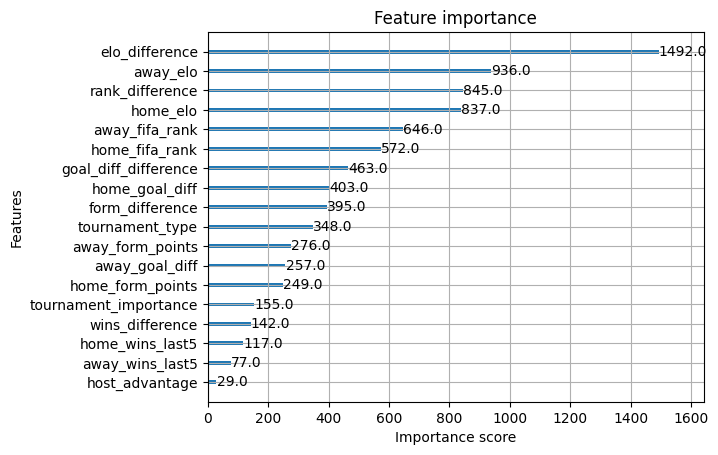

In [276]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(best_xgb, max_num_features=20)
plt.show()

# Model Comparison

Random Forest and XGBoost are compared using the same train-test split and evaluation metrics.

The objective is to identify the model that provides the best balance between predictive accuracy, stability, and generalization performance for FIFA World Cup match prediction.

In [277]:
rf_accuracy = accuracy_score(y_test, rf_predictions)



rf_weighted_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_macro_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro"
)

rf_cv_mean = scores.mean()

rf_cv_std = scores.std()

In [278]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)



xgb_weighted_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted"
)

xgb_macro_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="macro"
)

xgb_cv_mean = scores.mean()

xgb_cv_std = scores.std()

In [279]:
comparison = pd.DataFrame({

    "Metric":[

        "Test Accuracy",
        
        "Weighted F1 Score",

        "Macro F1 Score",

        "Mean CV Accuracy",

        "CV Std Dev"

    ],

    "Random Forest":[

        rf_accuracy,

        rf_weighted_f1,

        rf_macro_f1,

        rf_cv_mean,

        rf_cv_std

    ],

    "XGBoost":[

        xgb_accuracy,

        xgb_weighted_f1,

        xgb_macro_f1,

        xgb_cv_mean,

        xgb_cv_std

    ]

})

comparison

,Metric,Random Forest,XGBoost
0,Test Accuracy,0.652563,0.654190
1,Weighted F1 Score,0.611525,0.597920
2,Macro F1 Score,0.543376,0.520983
3,Mean CV Accuracy,0.650008,0.650008
4,CV Std Dev,0.005109,0.005109


In [280]:
if rf_accuracy > xgb_accuracy:

    print("🏆 Final Model : Random Forest")

else:

    print("🏆 Final Model : XGBoost")

🏆 Final Model : XGBoost


# Final Model Selection

Both Random Forest and XGBoost were evaluated using the same engineered feature set and 5-fold cross-validation.

Although both models achieved comparable performance, XGBoost produced the highest test accuracy while maintaining similar cross-validation performance and stability.

Therefore, XGBoost was selected as the final prediction model for the FIFA World Cup Match Prediction System. This model will be integrated into the web application and used for Monte Carlo tournament simulation.

In [281]:
probabilities = best_xgb.predict_proba(X_test)

print(probabilities[:5])

[[0.20039009 0.3590251  0.44058487]
 [0.47593766 0.30529976 0.21876256]
 [0.385852   0.29825762 0.3158903 ]
 [0.03674329 0.11664943 0.84660727]
 [0.0899239  0.2805142  0.6295619 ]]


In [282]:
match = 0

print(f"Home Win : {probabilities[match][0]:.2%}")
print(f"Draw     : {probabilities[match][1]:.2%}")
print(f"Away Win : {probabilities[match][2]:.2%}")

Home Win : 20.04%
Draw     : 35.90%
Away Win : 44.06%


# Saving the Final Model

The trained XGBoost model is serialized using Joblib so it can be reused in the web application without retraining.

This significantly reduces inference time and enables seamless integration with the backend API.

In [283]:
import joblib

joblib.dump(
    best_xgb,
    "fifa_worldcup_xgboost.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [284]:
joblib.dump(
    list(X.columns),
    "feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [285]:
import os

print(os.listdir())

['.ipynb_checkpoints', '01_data_understanding.ipynb', '02_feature_engineering.ipynb', '03_prediction_engine.ipynb', 'feature_columns.pkl', 'fifa_worldcup_xgboost.pkl']


In [286]:
print(y.unique())

[1 2 0]


In [292]:
print(best_xgb.classes_)

[0 1 2]


In [293]:
print(y.head(10))

19    1
20    2
21    2
22    2
24    2
25    2
26    1
27    1
29    0
30    2
Name: result, dtype: int64


In [294]:
training_data[["home_score", "away_score", "result"]].head(10)

NameError: name 'training_data' is not defined

In [295]:
[name for name in globals().keys() if isinstance(globals()[name], pd.DataFrame)]

['___',
 'results',
 'elo',
 'recent_matches',
 '_5',
 '_8',
 '_9',
 '_10',
 '_12',
 'latest_elo',
 'fixtures',
 '_16',
 '_18',
 'historical_elo',
 '_21',
 'current_elo',
 '_25',
 '_29',
 '_30',
 '_31',
 '_33',
 'elo_long',
 '_35',
 '_37',
 'teams',
 '_44',
 '_47',
 '_54',
 '_57',
 '_67',
 '_81',
 '_96',
 '_102',
 'fifa',
 '_109',
 '_117',
 '_123',
 '_126',
 '_128',
 '_134',
 'matches',
 '_138',
 '_145',
 '_150',
 '_151',
 '_154',
 '_157',
 'X',
 'X_train',
 'X_test',
 'importance',
 '_172',
 'comparison',
 '_279']

In [296]:
comparison.head(10)

,Metric,Random Forest,XGBoost
0,Test Accuracy,0.652563,0.654190
1,Weighted F1 Score,0.611525,0.597920
2,Macro F1 Score,0.543376,0.520983
3,Mean CV Accuracy,0.650008,0.650008
4,CV Std Dev,0.005109,0.005109


In [297]:
X_train.join(y).head(10)

,home_elo,away_elo,elo_difference,home_fifa_rank,away_fifa_rank,rank_difference,home_form_points,away_form_points,form_difference,home_goal_diff,away_goal_diff,goal_diff_difference,home_wins_last5,away_wins_last5,wins_difference,host_advantage,tournament_type,tournament_importance,result
17518,917.0,977.0,-60.0,138.0,152.0,14.0,2,4,-2,-6,-5,-1,0,1,-1,0,6,1,0
12737,1214.0,1406.0,-192.0,135.0,99.0,-36.0,1,4,-3,-10,-6,-4,0,1,-1,0,8,2,1
4324,1314.0,1229.0,85.0,121.0,123.0,2.0,12,4,8,5,-5,10,4,1,3,0,6,2,2
7664,1589.0,1309.0,280.0,57.0,167.0,110.0,8,4,4,3,-4,7,2,1,1,0,6,2,2
1978,1322.0,1266.0,56.0,112.0,125.0,13.0,6,13,-7,-7,11,-18,2,4,-2,0,7,2,2
14416,1707.0,1829.0,-122.0,73.0,37.0,-36.0,2,1,1,-4,-4,0,0,0,0,0,5,1,0
15851,1471.0,1362.0,109.0,66.0,90.0,24.0,7,3,4,-2,-6,4,2,1,1,0,6,1,0
7219,1544.0,1342.0,202.0,85.0,113.0,28.0,15,3,12,8,-3,11,5,1,4,0,6,2,2
7651,1505.0,1686.0,-181.0,59.0,77.0,18.0,6,5,1,0,-2,2,2,1,1,0,7,2,1
11140,815.0,1036.0,-221.0,176.0,171.0,-5.0,4,7,-3,-4,-3,-1,1,2,-1,0,8,2,1


In [298]:
[name for name in globals().keys() if name.startswith("X")]

['X', 'X_train', 'X_test', 'XGBClassifier']

In [299]:
X_train.join(y)[["result"]].head(10)

,result
17518,0
12737,1
4324,2
7664,2
1978,2
14416,0
15851,0
7219,2
7651,1
11140,1


In [300]:
results.loc[X_train.index, ["home_score", "away_score", "result"]].head(10)

KeyError: "['result'] not in index"

In [301]:
print(results.columns)

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')


In [302]:
[name for name in globals().keys()
 if isinstance(globals()[name], pd.DataFrame)
 and "result" in globals()[name].columns]

['_', '___', 'recent_matches', '_5', 'matches', '_138', '_154', '_297', '_299']

In [303]:
matches[["home_score", "away_score", "result"]].head(20)

,home_score,away_score,result
148,2.0,1.0,2
232,0.0,1.0,0
283,3.0,1.0,2
496,0.0,1.0,0
516,0.0,2.0,0
532,5.0,0.0,2
554,0.0,1.0,0
566,0.0,3.0,0
599,3.0,0.0,2
624,3.0,2.0,2
